# Inside Out 2 감정 캐릭터 표정 분석 데모 



In [13]:
from google.colab import drive
import os
drive.mount('/content/drive')
wanted_folder_path = '/content/drive/MyDrive/인지프'

# 3. 해당 폴더로 작업 디렉토리 이동
os.chdir(wanted_folder_path)

Mounted at /content/drive


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
print("현재 작업 폴더:", os.getcwd())

현재 작업 폴더: /content/drive/My Drive/인지프


## 0. 설치
처음 한 번만 실행하면 됩니다.

In [16]:
!pip install --upgrade torchao peft transformers #LoRA를 위해 추가

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 68.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.9.0
    Uninstalling transformers-5.9.0:
      Successfully uninstalled transformers-5.9.0


In [17]:
!pip install -q opencv-python pillow pandas numpy matplotlib tqdm transformers accelerate torch torchvision google-genai selenium beautifulsoup4 svg.path

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 7.5 MB/s eta 0:00:00


작업일: 2026-05-30

In [18]:
# # Remove broken Chromium / ChromeDriver stubs if they exist
!apt-get update -qq
!apt-get remove -y chromium-browser chromium-chromedriver || true

# # Install Google Chrome stable
!wget -q -O /tmp/google-chrome.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y /tmp/google-chrome.deb

# # Upgrade Selenium so Selenium Manager can manage ChromeDriver automatically
!pip install -q -U selenium

# # Check Chrome installation
!google-chrome --version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package 'chromium-browser' is not installed, so not removed
Package 'chromium-chromedriver' is not installed, so not removed
0 upgraded, 0 newly installed, 0 to remove and 56 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of '/tmp/google-chrome.deb'
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridg

이 코드는 output 폴더 삭제용이므로 재실행할 때 주의하세요!!!!

In [ ]:
import shutil
import os

# 삭제할 대상 폴더 이름
OUTPUT_DIR = "insideout2_output"

# 폴더가 존재하는지 확인하고 삭제
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
    print(f"🧹 '{OUTPUT_DIR}' 폴더와 그 안의 모든 파일이 깔끔하게 삭제되었습니다!")
else:
    print(f"🤷‍♂️ '{OUTPUT_DIR}' 폴더가 존재하지 않습니다. (이미 지워졌거나 이름이 다릅니다)")

## 0. 기본 설정

작업일: 2026-05-30
- 라이브러리 추가

In [19]:
import os
import cv2
import math
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel
from peft import LoraConfig, get_peft_model
from peft import PeftModel
from PIL import Image
from tqdm import tqdm
from transformers import pipeline, CLIPProcessor, CLIPModel

from google import genai
from google.genai import types
import json
import re

import time
from bs4 import BeautifulSoup
from urllib.parse import urlparse, parse_qs

import uuid
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver import ActionChains
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [20]:
youtube_url = "https://www.youtube.com/watch?v=vW0IQoSweVI"
# youtube_url = input("하이라이트 클립을 추출할 YouTube 영상 URL을 입력하세요: ")

In [21]:
# 로컬에서 실행할 경우 본인 영상 경로로 수정하세요.
# 예: VIDEO_PATH = r"C:\\Users\\young\\Downloads\\인사이드아웃2.mp4"
# VIDEO_PATH = "sample_data/video.mp4"
VIDEO_PATH = r"/content/drive/MyDrive/인지프/인사이드아웃요약.mp4"

OUTPUT_DIR = "/content/drive/MyDrive/인지프/insideout2_output"
SAMPLE_FPS = 1          # 1초에 1장씩 프레임 추출
DETECTION_THRESHOLD = 0.08
WINDOW_SIZE = 5         # 하이라이트 후보 계산 단위: 5초
STEP_SIZE = 5           # 겹치지 않는 5초 구간
TOP_K_HIGHLIGHTS = 3    # 상위 하이라이트 후보 개수

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_ID = 0 if DEVICE == "cuda" else -1

### ★ LLM 추가 (Character Profile Definition 단계 자동화)
작업일: 2026-05-24

- func: 영화명을 입력하면 LLM이 캐릭터 프로필 딕셔너리를 자동 생성하는 함수
- input: 영화명
- output: 영화 캐릭터 프로필 딕셔너리
- day limit: 최대 500RPD까지 사용가능 (참고: https://ai.google.dev/gemini-api/docs/pricing?hl=ko)

In [22]:
def extract_json(text):
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError("JSON object를 찾지 못했습니다.")

    return text[start:end + 1]

In [23]:
# API 키를 노트북에 직접 적지 않습니다.
# Colab에서는 왼쪽 Secrets 메뉴에 GEMINI_API_KEY를 등록하는 방식을 권장합니다.
try:
    from google.colab import userdata
    api_key = userdata.get("GEMINI_API_KEY")
except Exception:
    api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    from getpass import getpass
    api_key = getpass("Gemini API key를 입력하세요: ")


Gemini API key를 입력하세요: ··········


In [24]:
movie_title = input("🎥 영화 제목을 입력하세요: ")

🎥 영화 제목을 입력하세요: insideout2


작업일: 2026-06-05
- 프롬프트 수정 (캐릭터-사물 오탐과 parsing 오류 가능성을 줄임)
1. OWL-ViT query가 색상·소품·의상 등 단일 feature가 아닌 전체 캐릭터를 대상으로 생성되도록 제한
2. comma 사용 금지
3. non-character object 제외
4. character 지시어 포함

In [25]:
llm_prompt = f"""
You are an expert assistant for an animation character detection and emotion analysis project.

Given the movie title below, generate a character profile dictionary for zero-shot character detection using OWL-ViT.

Movie title: {movie_title}

Return ONLY valid JSON.
Do not include markdown, code fences, explanations, or comments.

The JSON must follow this exact structure:

{{
  "CharacterName": {{
    "korean": "KoreanName",
    "expected_emotion": "emotion",
    "queries": [
      "short whole character detection phrase 1",
      "short whole character detection phrase 2",
      "short whole character detection phrase 3"
    ]
  }}
}}

Your output will be used directly as OWL-ViT candidate labels.
Therefore, each query MUST describe the WHOLE animated character, not a body part, clothing item, color patch, prop, background object, symbol, or object-like feature.

Core task:
- Identify only the main recurring animated characters in the movie.
- The goal is to detect visible characters in frames and then analyze their facial/emotional expression.
- Prefer characters with a recognizable face, body, or full character silhouette.

Character inclusion rules:
- Include only named, recurring, visually recognizable animated characters.
- Include human-like characters, creature-like characters, emotion characters, animal characters, robot characters, or anthropomorphic characters only if they are recurring characters.
- Do NOT include props, vehicles, rooms, buildings, food, toys, signs, logos, clothing, weapons, furniture, background objects, abstract shapes, or scene elements.
- Do NOT include a character if it is mostly a non-recurring object or one-time background element.
- Do NOT create separate entries for a character's clothing, hair, eyes, accessories, or carried items.

Query generation rules:
- Each query must be written in English only.
- Each query must be a short phrase under 16 tokens.
- Do NOT use commas inside query strings.
- Do NOT write standalone visual features such as "blue hair", "green dress", "red square", "glasses", "yellow skin", or "purple hoodie".
- Every query must contain one of these words: "character", "cartoon character", "animated character", or "movie character".
- Every query must refer to the whole character using a combination of name, movie title, and visual identity.
- Good queries should help OWL-ViT detect the complete character body or face, not just an object-like feature.
- Avoid overly generic queries such as "red character", "blue character", "small character", or "angry character" unless combined with the character name and movie title.
- Do not describe emotional state as the main visual feature unless it is part of the character identity.

Required query pattern:
For each character, create 3 to 5 queries:
1. Character name + movie title + "animated character"
2. Character name + "cartoon character"
3. Whole-body visual identity + "animated character"
4. Face/body visual identity + "cartoon character"
5. Optional: character name + distinctive non-object visual trait + "movie character"

Expected emotion rules:
- expected_emotion must be lowercase English.
- expected_emotion MUST be exactly one of the following 7 emotions:
  happy, sad, angry, fearful, disgusted, surprised, neutral
- Do NOT use any other emotion labels.
- Map similar emotions to the closest allowed label:
  anxious -> fearful
  jealous -> angry
  bored -> neutral
  embarrassed -> fearful
  annoyed -> angry
  confused -> surprised
  calm -> neutral

Korean name rules:
- "korean" should be the commonly used Korean character name if known.
- If the Korean name is uncertain, translate the English name naturally into Korean.

Quality control before final answer:
- Check that every query describes a whole character.
- Check that no query is only a color, body part, clothing item, prop, or background object.
- Check that no query contains commas.
- Check that the JSON is valid and directly parsable by json.loads().
"""

In [26]:
import os
# API 키 설정
# api_key 변수가 딕셔너리 형태일 경우 실제 키 값을 추출합니다.
if isinstance(api_key, dict) and 'data' in api_key and 'payload' in api_key['data']:
    actual_api_key = api_key['data']['payload']
else:
    actual_api_key = api_key

client = genai.Client(api_key=actual_api_key)

# Gemini 로드: 프롬프트를 사용하여 캐릭터 프로필 딕셔너리 생성
response = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents=llm_prompt,
    config=types.GenerateContentConfig(
        tools=[types.Tool(google_search=types.GoogleSearch())]
    )
)

In [27]:
import json
import re

# JSON 문자열을 Python dict로 변환
json_text = extract_json(response.text)

# `json_text`에 LLM이 생성한 불필요한 추가 텍스트가 포함되어 있을 경우를 대비하여
# json.JSONDecoder().raw_decode를 사용하여 첫 번째 유효한 JSON 객체만 추출합니다.
try:
    decoder = json.JSONDecoder()
    # raw_decode는 (디코딩된 객체, JSON 문자열의 끝 인덱스)를 반환합니다.
    # 우리는 디코딩된 객체만 필요합니다.
    parsed_obj, _ = decoder.raw_decode(json_text)
    CHARACTERS = parsed_obj
except json.JSONDecodeError as e:
    # 만약 json_text가 유효한 JSON으로 시작하지 않는다면, 첫 번째 '{'를 찾아서 다시 시도합니다.
    start_brace_idx = json_text.find('{')
    if start_brace_idx != -1:
        try:
            decoder = json.JSONDecoder()
            parsed_obj, _ = decoder.raw_decode(json_text[start_brace_idx:])
            CHARACTERS = parsed_obj
        except json.JSONDecodeError:
            # 여전히 디코딩에 실패하면 오류를 다시 발생시킵니다.
            raise ValueError(f"텍스트에서 유효한 JSON 객체를 추출할 수 없습니다: {e}")
    else:
        # '{'도 찾을 수 없으면 오류를 발생시킵니다.
        raise ValueError(f"텍스트에서 유효한 JSON 객체를 찾을 수 없습니다: {e}")

print(CHARACTERS)

{'Riley Andersen': {'korean': '라일리 앤더슨', 'expected_emotion': 'neutral', 'queries': ['Riley Andersen Inside Out 2 animated character', 'Riley Andersen cartoon character', 'teenage girl animated character', 'Inside Out 2 main character cartoon character', 'Riley Andersen movie character']}, 'Joy': {'korean': '기쁨', 'expected_emotion': 'happy', 'queries': ['Joy Inside Out 2 animated character', 'Joy cartoon character', 'yellow emotion animated character', 'Inside Out 2 Joy cartoon character', 'Joy movie character']}, 'Sadness': {'korean': '슬픔', 'expected_emotion': 'sad', 'queries': ['Sadness Inside Out 2 animated character', 'Sadness cartoon character', 'blue emotion animated character', 'Inside Out 2 Sadness cartoon character', 'Sadness movie character']}, 'Anger': {'korean': '버럭', 'expected_emotion': 'angry', 'queries': ['Anger Inside Out 2 animated character', 'Anger cartoon character', 'red emotion animated character', 'Inside Out 2 Anger cartoon character', 'Anger movie character']}, 

작업일: 2025-05-30
- 7 Emotions version으로 수정

In [28]:
'''
# 기존 버전

# Inside Out 1 + Inside Out 2 감정 캐릭터
# expected_emotion은 캐릭터가 원래 대표하는 감정입니다.
# CLIP zero-shot 감정 분류의 불확실성을 줄이기 위해 세부 감정은 7개 상위 감정으로 매핑했습니다.
# anxious -> fearful, jealous -> angry, bored -> neutral, embarrassed -> fearful
CHARACTERS = {
    "Joy": {
        "korean": "기쁨이",
        "expected_emotion": "happy",
        "queries": [
            "Joy from Inside Out 2",
            "blue hair yellow dress cartoon character",
            "yellow happy emotion character with blue hair",
        ],
    },
    "Sadness": {
        "korean": "슬픔이",
        "expected_emotion": "sad",
        "queries": [
            "Sadness from Inside Out 2",
            "blue sad cartoon character with glasses",
            "blue emotion character with glasses and sweater",
        ],
    },
    "Anger": {
        "korean": "버럭이",
        "expected_emotion": "angry",
        "queries": [
            "Anger from Inside Out 2",
            "red angry cartoon character",
            "red square angry emotion character",
        ],
    },
    "Fear": {
        "korean": "소심이",
        "expected_emotion": "fearful",
        "queries": [
            "Fear from Inside Out 2",
            "purple fearful cartoon character",
            "purple scared emotion character",
        ],
    },
    "Disgust": {
        "korean": "까칠이",
        "expected_emotion": "disgusted",
        "queries": [
            "Disgust from Inside Out 2",
            "green disgusted cartoon character",
            "green emotion character disgust face",
        ],
    },
    "Anxiety": {
        "korean": "불안이",
        "expected_emotion": "fearful",
        "queries": [
            "Anxiety from Inside Out 2",
            "orange anxious cartoon character Inside Out 2",
            "orange nervous emotion character",
        ],
    },
    "Envy": {
        "korean": "부럽이",
        "expected_emotion": "angry",
        "queries": [
            "Envy from Inside Out 2",
            "small teal jealous cartoon character Inside Out 2",
            "turquoise envy emotion character",
        ],
    },
    "Ennui": {
        "korean": "따분이",
        "expected_emotion": "neutral",
        "queries": [
            "Ennui from Inside Out 2",
            "purple bored cartoon character Inside Out 2",
            "bored tired emotion character",
        ],
    },
    "Embarrassment": {
        "korean": "당황이",
        "expected_emotion": "fearful",
        "queries": [
            "Embarrassment from Inside Out 2",
            "large pink embarrassed cartoon character Inside Out 2",
            "pink shy emotion character with hoodie",
        ],
    },
}

'''

'\n# 기존 버전\n\n# Inside Out 1 + Inside Out 2 감정 캐릭터\n# expected_emotion은 캐릭터가 원래 대표하는 감정입니다.\n# CLIP zero-shot 감정 분류의 불확실성을 줄이기 위해 세부 감정은 7개 상위 감정으로 매핑했습니다.\n# anxious -> fearful, jealous -> angry, bored -> neutral, embarrassed -> fearful\nCHARACTERS = {\n    "Joy": {\n        "korean": "기쁨이",\n        "expected_emotion": "happy",\n        "queries": [\n            "Joy from Inside Out 2",\n            "blue hair yellow dress cartoon character",\n            "yellow happy emotion character with blue hair",\n        ],\n    },\n    "Sadness": {\n        "korean": "슬픔이",\n        "expected_emotion": "sad",\n        "queries": [\n            "Sadness from Inside Out 2",\n            "blue sad cartoon character with glasses",\n            "blue emotion character with glasses and sweater",\n        ],\n    },\n    "Anger": {\n        "korean": "버럭이",\n        "expected_emotion": "angry",\n        "queries": [\n            "Anger from Inside Out 2",\n            "red angry cartoon character",

작업일: 2025-05-30
- 7 Emotions version으로 수정

In [29]:
# CLIP 감정 분류용 라벨과 프롬프트
# EMOTIONS와 CLIP_EMOTION_PROMPTS의 길이가 반드시 같아야 합니다.
# 11개 세부 감정 대신 7개 상위 감정만 사용하여 CLIP 분류 안정성을 높였습니다.
EMOTIONS = [
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgusted",
    "surprised",
    "neutral",
]

CLIP_EMOTION_PROMPTS = [
    "a close-up of a cartoon character with a happy smiling face",
    "a close-up of a cartoon character with a sad crying face",
    "a close-up of a cartoon character with an angry furious face",
    "a close-up of a cartoon character with a fearful scared face",
    "a close-up of a cartoon character with a disgusted face",
    "a close-up of a cartoon character with a surprised shocked face",
    "a close-up of a cartoon character with a neutral calm face",
]

assert len(EMOTIONS) == len(CLIP_EMOTION_PROMPTS), "EMOTIONS와 CLIP_EMOTION_PROMPTS 길이가 달라요."


# 감정 불일치 점수표
# 행: 캐릭터의 대표 감정, 열: 실제로 예측된 감정
# 0에 가까울수록 대표 감정과 일치, 1에 가까울수록 불일치가 큼
# 7개 감정 라벨 기준으로 단순화했습니다.
MISMATCH_TABLE = {
    "happy": {
        "happy": 0.0, "neutral": 0.4, "surprised": 0.5,
        "fearful": 0.8, "sad": 1.0, "angry": 1.0, "disgusted": 0.9,
    },
    "sad": {
        "sad": 0.0, "neutral": 0.4, "fearful": 0.7,
        "surprised": 0.7, "angry": 0.8, "disgusted": 0.8, "happy": 1.0,
    },
    "angry": {
        "angry": 0.0, "neutral": 0.4, "disgusted": 0.5,
        "surprised": 0.6, "fearful": 0.8, "sad": 0.8, "happy": 1.0,
    },
    "fearful": {
        "fearful": 0.0, "surprised": 0.4, "neutral": 0.5,
        "sad": 0.7, "disgusted": 0.8, "angry": 0.9, "happy": 1.0,
    },
    "disgusted": {
        "disgusted": 0.0, "neutral": 0.4, "angry": 0.5,
        "sad": 0.7, "surprised": 0.7, "fearful": 0.8, "happy": 1.0,
    },
    "surprised": {
        "surprised": 0.0, "fearful": 0.4, "happy": 0.6,
        "neutral": 0.6, "sad": 0.7, "disgusted": 0.8, "angry": 0.8,
    },
    "neutral": {
        "neutral": 0.0, "happy": 0.5, "sad": 0.5,
        "disgusted": 0.5, "surprised": 0.6, "fearful": 0.7, "angry": 0.8,
    },
}



print('사용 장치:', DEVICE)
print('영상 경로:', VIDEO_PATH)
print('결과 폴더:', OUTPUT_DIR)
print('분석 캐릭터 수:', len(CHARACTERS))
print('감정 라벨 수:', len(EMOTIONS))

사용 장치: cuda
영상 경로: /content/drive/MyDrive/인지프/인사이드아웃요약.mp4
결과 폴더: /content/drive/MyDrive/인지프/insideout2_output
분석 캐릭터 수: 11
감정 라벨 수: 7


## 1. 폴더 생성 및 공통 함수

In [30]:
def prepare_dirs():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/frames", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/crops", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/annotated_frames", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/highlight_clips", exist_ok=True)


def seconds_to_time(sec):
    sec = int(sec)
    m = sec // 60
    s = sec % 60
    return f"{m:02d}:{s:02d}"


def entropy(values):
    if len(values) == 0:
        return 0.0
    counts = pd.Series(values).value_counts(normalize=True)
    ent = -sum(p * math.log(p + 1e-9) for p in counts)
    max_ent = math.log(len(EMOTIONS))
    return float(ent / max_ent) if max_ent > 0 else 0.0

def is_blurry(image, threshold=20):
    """라플라시안 변산도를 이용하여 너무 흔들린 프레임을 걸러냅니다."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance < threshold

def is_poor_lighting(image, low=30, high=225):
    """영상의 평균 밝기를 계산하여 너무 어둡거나 하얗게 날아간 프레임을 걸러냅니다."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    avg_brightness = np.mean(gray)
    return avg_brightness < low or avg_brightness > high

def is_duplicate(img1, img2, threshold=0.85):
    """이전 프레임과 비교하여 화면이 거의 변하지 않은 중복 프레임을 걸러냅니다."""
    if img1 is None or img2 is None:
        return False

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # 두 이미지의 유사도 계산
    res = cv2.matchTemplate(gray1, gray2, cv2.TM_CCORR_NORMED)
    similarity = res[0][0]
    return similarity > threshold

prepare_dirs()
print('결과 저장 폴더 준비 완료')

결과 저장 폴더 준비 완료


## 2. 영상에서 프레임 추출

In [31]:
def extract_frames(video_path, sample_fps=1):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"영상을 열 수 없습니다: {video_path}")

    original_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / original_fps if original_fps > 0 else 0
    frame_interval = max(1, int(original_fps / sample_fps))

    print("\n[1단계] 프레임 추출 및 통합 품질 필터링 (중복 포함)")
    print(f"원본 FPS: {original_fps:.2f} | 총 프레임 수: {total_frames} | 영상 길이: {duration:.2f}초")
    print(f"추출 기준: {sample_fps} FPS")

    # 4종류의 저장 폴더 생성 (정상, 블러, 조명, 중복)
    os.makedirs(os.path.join(OUTPUT_DIR, "frames"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "dropped_blur_frames"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "dropped_light_frames"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "dropped_duplicate_frames"), exist_ok=True)

    # 데이터 기록용 리스트
    frame_infos = []
    dropped_blur_infos = []
    dropped_light_infos = []
    dropped_dup_infos = []

    # 각 폴더별 파일 이름 카운터
    frame_idx = 0
    saved_idx = 0
    blur_idx = 0
    light_idx = 0
    dup_idx = 0

    # 통계용 카운터
    dropped_blur = 0
    dropped_light = 0
    dropped_dup = 0

    prev_frame = None

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_interval == 0:
            timestamp = frame_idx / original_fps
            timestamp_str = seconds_to_time(timestamp) # 기존 시간 변환 함수 사용

            # 1. 모션 블러 필터링 (30이상으로 설정 금지!)
            if is_blurry(frame):
                dropped_blur += 1
                blur_name = f"blur_{blur_idx:05d}.jpg"
                blur_path = os.path.join(OUTPUT_DIR, "dropped_blur_frames", blur_name)

                cv2.imwrite(blur_path, frame) # 블러 이미지 저장
                dropped_blur_infos.append({
                    "drop_id": blur_idx, "original_frame_idx": frame_idx,
                    "frame_path": blur_path, "timestamp": timestamp,
                    "timestamp_str": timestamp_str, "drop_reason": "blur"
                })
                blur_idx += 1
                frame_idx += 1
                continue

            # 2. 조명 불량 필터링
            if is_poor_lighting(frame):
                dropped_light += 1
                light_name = f"light_{light_idx:05d}.jpg"
                light_path = os.path.join(OUTPUT_DIR, "dropped_light_frames", light_name)

                cv2.imwrite(light_path, frame) # 조명 불량 이미지 저장
                dropped_light_infos.append({
                    "drop_id": light_idx, "original_frame_idx": frame_idx,
                    "frame_path": light_path, "timestamp": timestamp,
                    "timestamp_str": timestamp_str, "drop_reason": "poor_lighting"
                })
                light_idx += 1
                frame_idx += 1
                continue

            # 3. 중복 프레임 필터링 (★추가된 부분)
            if is_duplicate(frame, prev_frame):
                dropped_dup += 1
                dup_name = f"dup_{dup_idx:05d}.jpg"
                dup_path = os.path.join(OUTPUT_DIR, "dropped_duplicate_frames", dup_name)

                cv2.imwrite(dup_path, frame) # 중복 이미지 저장
                dropped_dup_infos.append({
                    "drop_id": dup_idx, "original_frame_idx": frame_idx,
                    "frame_path": dup_path, "timestamp": timestamp,
                    "timestamp_str": timestamp_str, "drop_reason": "duplicate"
                })
                dup_idx += 1
                frame_idx += 1
                continue

            # 4. 모든 필터를 통과한 정상 프레임 저장
            frame_name = f"frame_{saved_idx:05d}.jpg"
            frame_path = os.path.join(OUTPUT_DIR, "frames", frame_name)

            cv2.imwrite(frame_path, frame)
            prev_frame = frame.copy() # 다음 프레임과 비교하기 위해 저장

            frame_infos.append({
                "frame_id": saved_idx, "original_frame_idx": frame_idx,
                "frame_path": frame_path, "timestamp": timestamp,
                "timestamp_str": timestamp_str,
            })
            saved_idx += 1

        frame_idx += 1

    cap.release()

    # 각각의 리스트를 데이터프레임으로 변환 후 CSV 저장
    frame_df = pd.DataFrame(frame_infos)
    blur_df = pd.DataFrame(dropped_blur_infos)
    light_df = pd.DataFrame(dropped_light_infos)
    dup_df = pd.DataFrame(dropped_dup_infos)

    frame_df.to_csv(f"{OUTPUT_DIR}/extracted_frames.csv", index=False, encoding="utf-8-sig")
    blur_df.to_csv(f"{OUTPUT_DIR}/dropped_blur_frames.csv", index=False, encoding="utf-8-sig")
    light_df.to_csv(f"{OUTPUT_DIR}/dropped_light_frames.csv", index=False, encoding="utf-8-sig")
    dup_df.to_csv(f"{OUTPUT_DIR}/dropped_duplicate_frames.csv", index=False, encoding="utf-8-sig")

    print(f"\n--- 1그룹 필터링 결과 요약 ---")
    print(f"제거된 블러 프레임: {dropped_blur}장")
    print(f"제거된 조명 불량 프레임: {dropped_light}장")
    print(f"제거된 중복 프레임: {dropped_dup}장")
    print(f"✅ 최종 추출 및 정상 저장 완료: {len(frame_df)}장")

    return frame_df, blur_df, light_df, dup_df

## 3. 모델 로딩

In [32]:
def load_models():
    print("\n[2단계] 모델 로딩")
    print(f"사용 장치: {DEVICE}")

    print("Zero-shot object detection 모델 로딩 중...")
    detector = pipeline(
        task="zero-shot-object-detection",
        model="google/owlvit-base-patch32",
        device=DEVICE_ID,
    )

    print("CLIP 감정 분류 모델 로딩 중...")
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    return detector, clip_model, clip_processor

## 4. 캐릭터 탐지 함수

NEW CELL 1: LoRA(A-EAA) 모델 빌드 및 데이터셋 정의

In [33]:
DATASET_PATH = wanted_folder_path
base_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
class AEAAAnimationDataset(Dataset):
    def __init__(self, base_dir, processor, emotion_list):
        self.base_dir = base_dir
        self.processor = processor
        self.emotion_list = emotion_list
        self.emotion_to_idx = {emotion: idx for idx, emotion in enumerate(self.emotion_list)}
        self.image_paths = []
        self.labels = []

        for emotion in self.emotion_list:
            emotion_dir = os.path.join(base_dir, emotion)
            if not os.path.exists(emotion_dir):
                continue
            for file_name in os.listdir(emotion_dir):
                if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                    self.image_paths.append(os.path.join(emotion_dir, file_name))
                    self.labels.append(self.emotion_to_idx[emotion])
        print(f"──► [A-EAA] 총 {len(self.image_paths)}개의 학습 데이터셋 확보.")

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        processed = self.processor(images=image, return_tensors="pt")
        return {"pixel_values": processed['pixel_values'].squeeze(0), "label": torch.tensor(self.labels[idx], dtype=torch.long)}

# 기존 로드된 base_model에 LoRA 이식
lora_config = LoraConfig(
    r=8, lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05, bias="none",
    modules_to_save=["visual_projection"]
)
lora_model = get_peft_model(base_model, lora_config).to(DEVICE)
lora_model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

trainable params: 884,736 || all params: 152,162,049 || trainable%: 0.5814


NEW CELL 2: LoRA Fine-Tuning 훈련 루프 가동

- DATASET_PATH에 각 EMOTIONS를 폴더명으로 하는 이미지셋 데이터 추가가 필요함
(이미지셋 데이터: https://drive.google.com/drive/folders/1Xlmxo1ZLh-ezao8QUM5nMgooZ1h-efdw?usp=share_link)

In [34]:
'''
import os

print("DATASET_PATH:", DATASET_PATH)
print("exists:", os.path.exists(DATASET_PATH))
print("folders:", os.listdir(DATASET_PATH))

for emotion in EMOTIONS:
    emotion_dir = os.path.join(DATASET_PATH, emotion)
    print(emotion, os.path.exists(emotion_dir),
          os.listdir(emotion_dir)[:5] if os.path.exists(emotion_dir) else "폴더 없음")
'''

'\nimport os\n\nprint("DATASET_PATH:", DATASET_PATH)\nprint("exists:", os.path.exists(DATASET_PATH))\nprint("folders:", os.listdir(DATASET_PATH))\n\nfor emotion in EMOTIONS:\n    emotion_dir = os.path.join(DATASET_PATH, emotion)\n    print(emotion, os.path.exists(emotion_dir),\n          os.listdir(emotion_dir)[:5] if os.path.exists(emotion_dir) else "폴더 없음")\n'

In [35]:
train_dataset = AEAAAnimationDataset(base_dir=DATASET_PATH, processor=clip_processor, emotion_list=EMOTIONS)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

emotion_prompts = [f"a photo of a character feeling {e}" for e in EMOTIONS]
text_inputs = clip_processor(text=emotion_prompts, padding=True, return_tensors="pt").to(DEVICE)

optimizer = torch.optim.AdamW(lora_model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

print("▶ A-EAA 어댑터 파인튜닝 시작...")
lora_model.train()
for epoch in range(3): # 빠른 테스트를 위해 우선 3에폭 진행
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        pixel_values = batch["pixel_values"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        outputs = lora_model(pixel_values=pixel_values, input_ids=text_inputs['input_ids'], attention_mask=text_inputs['attention_mask'])
        loss = criterion(outputs.logits_per_image, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} 완료 - Average Loss: {total_loss/len(train_loader):.4f}")

# 가중치 저장
OUTPUT_DIR = os.path.join(DATASET_PATH, "aeaa_lora_weights")
lora_model.save_pretrained(OUTPUT_DIR)
print(f"🎉 LoRA 가중치 저장 완료: {OUTPUT_DIR}")

──► [A-EAA] 총 378개의 학습 데이터셋 확보.
▶ A-EAA 어댑터 파인튜닝 시작...


Epoch 1: 100%|██████████| 24/24 [01:56<00:00,  4.86s/it]


Epoch 1 완료 - Average Loss: 1.7182


Epoch 2: 100%|██████████| 24/24 [00:08<00:00,  2.69it/s]


Epoch 2 완료 - Average Loss: 1.4415


Epoch 3: 100%|██████████| 24/24 [00:04<00:00,  4.88it/s]


Epoch 3 완료 - Average Loss: 1.2602
🎉 LoRA 가중치 저장 완료: /content/drive/MyDrive/인지프/aeaa_lora_weights


NEW CELL 3: LoRA 가중치를 오리지널 CLIP 모델에 이식

In [36]:
LORA_WEIGHTS_PATH = "/content/drive/MyDrive/인지프/aeaa_lora_weights"

In [37]:
# 원본 모델 위에 LoRA 어댑터 칩 꽂기 (A-EAA 탑재)
if os.path.exists(LORA_WEIGHTS_PATH):
    print("──► [A-EAA] 학습된 LoRA 가중치를 성공적으로 로드하여 CLIP에 결합합니다.")
    lora_clip_model = PeftModel.from_pretrained(base_model, LORA_WEIGHTS_PATH).to(DEVICE)
else:
    print("[경고] LoRA 가중치를 찾을 수 없어 원본 Zero-shot 모델을 그대로 사용합니다.")
    lora_clip_model = base_model

──► [A-EAA] 학습된 LoRA 가중치를 성공적으로 로드하여 CLIP에 결합합니다.


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


작업일: 2026-05-30
- 작업내용: 35줄 수정
- (기존) try: results = detector(image, candidate_labels=[clean_query], threshold=threshold)
- (수정) try: results = detector(image, candidate_labels=[sub_query], threshold=threshold)

In [38]:
def detect_characters_in_frame(frame_path, detector, threshold=DETECTION_THRESHOLD):
    image = Image.open(frame_path).convert("RGB")
    all_results = []

    tokenizer = detector.tokenizer

    for character_name, info in CHARACTERS.items():
        candidate_boxes = []

        for query in info["queries"]:
            clean_query = str(query).strip()
            if not clean_query:
                continue

            sub_queries = [q.strip() for q in clean_query.split(",") if q.strip()]
            for sub_query in sub_queries:
                tokens = tokenizer(sub_query)["input_ids"]
                original_token_count = len(tokens)

                if original_token_count > 16:
                    original_query = sub_query # 원본 보관
                    words = sub_query.split()

                    # 16토큰 이하가 될 때까지 뒤에서부터 단어 제거
                    while len(tokens) > 16 and len(words) > 1:
                        words.pop()
                        sub_query = " ".join(words)
                        tokens = tokenizer(sub_query)["input_ids"]

                    # 📢 사용자가 알 수 있도록 콘솔에 알림 출력
                    print(f"⚠️ [토큰 초과 자르기] 캐릭터: {character_name}")
                    print(f"   - 원본 ({original_token_count}토큰): '{original_query}'")
                    print(f"   - 변경 ({len(tokens)}토큰): '{sub_query}'\n")

            try:
                results = detector(image, candidate_labels=[sub_query], threshold=threshold)
            except Exception as e:
                print(f"탐지 오류: {frame_path}, {character_name}, {e}")
                results = []

            for r in results:
                candidate_boxes.append({
                    "character": character_name,
                    "character_ko": info["korean"],
                    "score": float(r["score"]),
                    "box": r["box"],
                    "query": query,
                })

        # 캐릭터별 가장 높은 점수의 box 하나만 사용
        if len(candidate_boxes) > 0:
            best = sorted(candidate_boxes, key=lambda x: x["score"], reverse=True)[0]
            all_results.append(best)

    return all_results

## 5. Crop 및 감정 분류 함수

In [39]:
def crop_box_from_image(frame_path, box, padding=0.08):
    image = Image.open(frame_path).convert("RGB")
    w, h = image.size

    xmin = int(box["xmin"])
    ymin = int(box["ymin"])
    xmax = int(box["xmax"])
    ymax = int(box["ymax"])

    bw = xmax - xmin
    bh = ymax - ymin
    pad_x = int(bw * padding)
    pad_y = int(bh * padding)

    xmin = max(0, xmin - pad_x)
    ymin = max(0, ymin - pad_y)
    xmax = min(w, xmax + pad_x)
    ymax = min(h, ymax + pad_y)

    crop = image.crop((xmin, ymin, xmax, ymax))
    return crop, (xmin, ymin, xmax, ymax)


def classify_emotion_with_clip(image_pil, lora_clip_model, clip_processor):
    """
    crop 이미지 1장을 [LoRA Fine-tuned (A-EAA)] 방식으로 감정 분류합니다.
    """
    inputs = clip_processor(
        text=CLIP_EMOTION_PROMPTS,
        images=image_pil,
        return_tensors="pt",
        padding=True,
    ).to(DEVICE)

    with torch.no_grad():
        outputs = lora_clip_model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_emotion = EMOTIONS[pred_idx]
    confidence = float(probs[pred_idx])
    prob_dict = {emotion: float(prob) for emotion, prob in zip(EMOTIONS, probs)}

    return pred_emotion, confidence, prob_dict


def get_mismatch_score(character, predicted_emotion):
    """
    캐릭터의 대표 감정과 실제 예측 감정의 불일치 점수를 반환합니다.
    예측 라벨이 표에 없더라도 코드가 멈추지 않도록 기본값 0.5를 사용합니다.
    """
    expected = CHARACTERS[character]["expected_emotion"]
    score = MISMATCH_TABLE.get(expected, {}).get(predicted_emotion, 0.5)
    return float(score), expected


## 6. 전체 프레임 분석

작업일: 2026-06-05
- 같은 bbox가 여러 캐릭터로 중복 잡히는 경우 NMS로 하나만 남김

In [40]:
def box_iou(box1, box2):
    x1 = max(box1["xmin"], box2["xmin"])
    y1 = max(box1["ymin"], box2["ymin"])
    x2 = min(box1["xmax"], box2["xmax"])
    y2 = min(box1["ymax"], box2["ymax"])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = max(0, box1["xmax"] - box1["xmin"]) * max(0, box1["ymax"] - box1["ymin"])
    area2 = max(0, box2["xmax"] - box2["xmin"]) * max(0, box2["ymax"] - box2["ymin"])

    union_area = area1 + area2 - inter_area

    if union_area == 0:
        return 0.0

    return inter_area / union_area


def deduplicate_cross_character_detections(detections, iou_threshold=0.90):
    """
    같은 프레임 안에서 거의 같은 bbox가 여러 캐릭터로 중복 탐지된 경우,
    detection score가 가장 높은 결과 1개만 남김.
    """
    detections = sorted(detections, key=lambda x: x["score"], reverse=True)
    kept = []

    for det in detections:
        duplicate = False

        for kept_det in kept:
            iou = box_iou(det["box"], kept_det["box"])

            if iou >= iou_threshold:
                duplicate = True
                break

        if not duplicate:
            kept.append(det)

    return kept

In [41]:
def analyze_frames(frame_df, detector, lora_clip_model, clip_processor, min_box_area=3600):
    """
    min_box_area: 캐릭터 박스의 최소 픽셀 면적 (기본값 3600 = 가로 60 x 세로 60)
    이 값보다 작게 탐지된 캐릭터는 표정을 읽을 수 없다고 판단하여 버림
    """
    print("캐릭터 탐지 및 필터링 (크기 제한)")
    rows = []

    # 크기 필터링으로 걸러진 횟수 기록용
    dropped_small_faces = 0

    for _, row in tqdm(frame_df.iterrows(), total=len(frame_df)):
        frame_id = int(row["frame_id"])
        frame_path = row["frame_path"]
        timestamp = float(row["timestamp"])
        timestamp_str = row["timestamp_str"]

        # OWL-ViT로 캐릭터 탐지
        detections = detect_characters_in_frame(
            frame_path,
            detector,
            threshold=DETECTION_THRESHOLD,
        )

        # 같은 bbox가 여러 캐릭터로 중복 탐지되는 문제 방지
        detections = deduplicate_cross_character_detections(detections, iou_threshold=0.90)

        for det_idx, det in enumerate(detections):
            character = det["character"]
            box = det["box"]
            detect_score = det["score"]

            # 너무 작은 얼굴 걸러내기
            width = box["xmax"] - box["xmin"]
            height = box["ymax"] - box["ymin"]
            box_area = width * height

            # 박스 면적이 설정한 최소 크기(2500)보다 작으면 감정 분석을 안 하고 스킵
            if box_area < min_box_area:
                dropped_small_faces += 1
                continue

            # 필터링을 통과한 '충분히 큰 얼굴'만 크롭하여 CLIP 감정 분석 진행
            crop_img, fixed_box = crop_box_from_image(frame_path, box)
            crop_name = f"frame_{frame_id:05d}_{character}_{det_idx}.jpg"
            crop_path = os.path.join(OUTPUT_DIR, "crops", crop_name)
            crop_img.save(crop_path)

            pred_emotion, emotion_conf, prob_dict = classify_emotion_with_clip(
                crop_img,
                lora_clip_model,
                clip_processor,
            )

            mismatch_score, expected_emotion = get_mismatch_score(character, pred_emotion)

            result = {
                "frame_id": frame_id,
                "timestamp": timestamp,
                "timestamp_str": timestamp_str,
                "frame_path": frame_path,
                "crop_path": crop_path,
                "character": character,
                "character_ko": CHARACTERS[character]["korean"],
                "expected_emotion": expected_emotion,
                "predicted_emotion": pred_emotion,
                "detection_score": detect_score,
                "emotion_confidence": emotion_conf,
                "mismatch_score": mismatch_score,
                "xmin": fixed_box[0],
                "ymin": fixed_box[1],
                "xmax": fixed_box[2],
                "ymax": fixed_box[3],
                "box_area": box_area, # 나중에 데이터 분석을 위해 면적도 저장해둡니다
            }

            for emo in EMOTIONS:
                result[f"prob_{emo}"] = prob_dict.get(emo, 0.0)

            rows.append(result)

    result_df = pd.DataFrame(rows)
    result_path = f"{OUTPUT_DIR}/character_emotion_results.csv"

    if len(result_df) > 0:
        result_df.to_csv(result_path, index=False, encoding="utf-8-sig")

    print(f"\n--- 2그룹 필터링 결과 요약 ---")
    print(f"너무 작아서 버려진 캐릭터 얼굴 수: {dropped_small_faces}개")
    print(f"✅ 최종 감정 분석 성공(저장 완료): {len(result_df)}개")

    return result_df


## 7. 결과 표시 프레임 생성

In [42]:
def draw_annotated_frames(result_df, frame_df):
    print("\n[4단계] 박스/감정 표시 프레임 생성")

    color_map = {
        "Joy": (0, 255, 255),
        "Sadness": (255, 100, 0),
        "Anger": (0, 0, 255),
        "Fear": (255, 0, 255),
        "Disgust": (0, 255, 0),
        "Anxiety": (0, 140, 255),
        "Envy": (255, 255, 0),
        "Ennui": (180, 0, 180),
        "Embarrassment": (203, 192, 255),
    }

    for _, frame_row in tqdm(frame_df.iterrows(), total=len(frame_df)):
        frame_id = int(frame_row["frame_id"])
        frame_path = frame_row["frame_path"]

        img = cv2.imread(frame_path)
        if img is None:
            continue

        sub = result_df[result_df["frame_id"] == frame_id]

        for _, r in sub.iterrows():
            character = r["character"]
            emotion = r["predicted_emotion"]
            mismatch = r["mismatch_score"]

            xmin = int(r["xmin"])
            ymin = int(r["ymin"])
            xmax = int(r["xmax"])
            ymax = int(r["ymax"])

            color = color_map.get(character, (255, 255, 255))
            cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 2)

            label = f"{character} | {emotion} | mismatch {mismatch:.2f}"
            cv2.putText(
                img,
                label,
                (xmin, max(20, ymin - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                color,
                2,
                cv2.LINE_AA,
            )

        out_path = f"{OUTPUT_DIR}/annotated_frames/frame_{frame_id:05d}.jpg"
        cv2.imwrite(out_path, img)

    print("annotated frame 저장 완료")


## 8. 하이라이트 점수 계산

In [43]:
def calculate_highlight_scores(result_df, window_size=10, step_size=5):
    print("\n[5단계] 하이라이트 점수 계산")

    if len(result_df) == 0:
        raise ValueError("분석 결과가 없습니다. DETECTION_THRESHOLD를 0.05 또는 0.03으로 낮춰보세요.")

    max_time = result_df["timestamp"].max()
    windows = []
    start = 0

    while start <= max_time:
        end = start + window_size
        sub = result_df[(result_df["timestamp"] >= start) & (result_df["timestamp"] < end)]

        if len(sub) == 0:
            start += step_size
            continue

        avg_mismatch = float(sub["mismatch_score"].mean())
        avg_conf = float(sub["emotion_confidence"].mean())
        character_count = int(sub["character"].nunique())
        emotion_count = int(sub["predicted_emotion"].nunique())
        emotion_entropy = entropy(sub["predicted_emotion"].tolist())

        transition_count = 0
        for ch in sub["character"].unique():
            ch_sub = sub[sub["character"] == ch].sort_values("timestamp")
            emotions = ch_sub["predicted_emotion"].tolist()
            for i in range(1, len(emotions)):
                if emotions[i] != emotions[i - 1]:
                    transition_count += 1

        transition_score = min(1.0, transition_count / 5)

        # 데모용 공식
        highlight_score = (
            0.45 * avg_mismatch
            + 0.25 * emotion_entropy
            + 0.20 * transition_score
            + 0.10 * min(1.0, character_count / 5)
        )

        windows.append({
            "start_sec": start,
            "end_sec": end,
            "start_time": seconds_to_time(start),
            "end_time": seconds_to_time(end),
            "num_detections": len(sub),
            "character_count": character_count,
            "emotion_count": emotion_count,
            "avg_mismatch": avg_mismatch,
            "emotion_entropy": emotion_entropy,
            "transition_score": transition_score,
            "avg_emotion_confidence": avg_conf,
            "highlight_score": highlight_score,
        })

        start += step_size

    score_df = pd.DataFrame(windows).sort_values("highlight_score", ascending=False)
    score_path = f"{OUTPUT_DIR}/highlight_scores.csv"
    score_df.to_csv(score_path, index=False, encoding="utf-8-sig")

    print(f"하이라이트 점수 저장 완료: {score_path}")
    print(score_df.head(10))
    return score_df

## ★ Youtube '가장 많이 다시 본 장면' Score 추출
- 작업일: 2026-05-30
- 참고: https://stackoverflow.com/questions/74464780/get-youtubes-most-replayed-data-through-web-scraping

In [44]:
def make_chrome_driver():
    # snap stub chromedriver를 무시하도록 설정
    os.environ["SE_SKIP_DRIVER_IN_PATH"] = "true"

    options = Options()
    options.binary_location = "/usr/bin/google-chrome"

    options.add_argument("--headless=new")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu")
    options.add_argument("--disable-software-rasterizer")
    options.add_argument("--window-size=1920,1080")
    options.add_argument("--lang=en-US")
    options.add_argument(f"--user-data-dir=/tmp/chrome-profile-{uuid.uuid4()}")

    # Service를 명시하지 않으면 Selenium Manager가 driver를 자동 관리함
    driver = webdriver.Chrome(options=options)
    return driver

In [45]:
def get_heatmap_svg_path_with_selenium(youtube_url, wait_sec=10):
    driver = make_chrome_driver()

    try:
        driver.get(youtube_url)
        time.sleep(wait_sec)

        try:
            video = driver.find_element(By.TAG_NAME, "video")
            driver.execute_script("arguments[0].muted = true;", video)
            driver.execute_script("arguments[0].play();", video)
            time.sleep(2)
        except Exception:
            pass

        soup = BeautifulSoup(driver.page_source, "html.parser")

        path = soup.find("path", {"class": "ytp-modern-heat-map"})

        if path is None:
            print("[SKIP] heatmap path 없음")
            return None

        d = path.get("d")

        if not d:
            print("[SKIP] heatmap path d 속성 없음")
            return None

        return d

    finally:
        driver.quit()

In [46]:
# YouTube replay score는 SVG heatmap 좌표를 min-max scaling하여 0~1 범위로 변환
def svg_path_d_to_second_level_replay_df(d, duration_sec):
    pairs = re.findall(r"(-?\d+(?:\.\d+)?)\s*,\s*(-?\d+(?:\.\d+)?)", d)

    if not pairs:
        raise ValueError("SVG path d에서 좌표를 찾지 못했습니다.")

    coord_df = pd.DataFrame(
        [(float(x), float(y)) for x, y in pairs],
        columns=["x", "y"]
    )

    # 실제 YouTube heatmap은 x축이 대체로 0~1000
    coord_df = coord_df.query("0 <= x <= 1000")

    if coord_df.empty:
        raise ValueError("유효한 heatmap 좌표가 없습니다.")

    # 같은 x값이 여러 번 나오면, y가 가장 낮은 점이 가장 높은 heatmap peak
    coord_df = (
        coord_df
        .groupby("x", as_index=False)["y"]
        .min()
        .sort_values("x")
    )

    # x 좌표를 실제 영상 초 단위로 변환
    coord_df["second_float"] = (
        (coord_df["x"] - coord_df["x"].min()) /
        (coord_df["x"].max() - coord_df["x"].min()) *
        duration_sec
    )

    # y가 낮을수록 많이 replay된 구간
    y_min = coord_df["y"].min()
    y_max = coord_df["y"].max()

    coord_df["youtube_replay_score"] = (
        0.0 if y_max == y_min
        else 1 - ((coord_df["y"] - y_min) / (y_max - y_min))
    )

    # 초 단위로 보간
    seconds = np.arange(0, int(np.ceil(duration_sec)) + 1)

    second_df = pd.DataFrame({
        "second": seconds,
        "youtube_replay_score": np.interp(
            seconds,
            coord_df["second_float"],
            coord_df["youtube_replay_score"]
        )
    })

    return second_df

In [47]:
from collections import Counter


def entropy_from_counts(counts):
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return float(-(probs * np.log2(probs)).sum())


def extract_video_id(youtube_url):
    parsed = urlparse(youtube_url)

    # 일반 YouTube URL: https://www.youtube.com/watch?v=VIDEO_ID
    if "youtube.com" in parsed.netloc:
        query = parse_qs(parsed.query)
        if "v" in query:
            return query["v"][0]

    # 짧은 URL: https://youtu.be/VIDEO_ID
    if "youtu.be" in parsed.netloc:
        return parsed.path.strip("/")

    raise ValueError("YouTube video_id를 추출하지 못했습니다.")


# valence: 부정(-1) ~ 긍정(+1), arousal: 차분(0) ~ 격앙(1)
# 감정 사이의 단순 불일치뿐 아니라 정서적 이동 방향과 강도를 수치화합니다.
EMOTION_COORDS = {
    "happy": (1.0, 0.7),
    "sad": (-0.8, 0.3),
    "angry": (-0.9, 1.0),
    "fearful": (-0.8, 0.9),
    "disgusted": (-0.7, 0.6),
    "surprised": (0.1, 1.0),
    "neutral": (0.0, 0.0),
}


def emotion_distance(expected, predicted):
    expected_coord = EMOTION_COORDS.get(expected, (0.0, 0.0))
    predicted_coord = EMOTION_COORDS.get(predicted, (0.0, 0.0))
    distance = np.linalg.norm(np.array(expected_coord) - np.array(predicted_coord))
    return float(np.clip(distance / np.sqrt(5), 0, 1))


def valence_flip(expected, predicted):
    expected_valence = EMOTION_COORDS.get(expected, (0.0, 0.0))[0]
    predicted_valence = EMOTION_COORDS.get(predicted, (0.0, 0.0))[0]
    return float(expected_valence * predicted_valence < 0)


def arousal_change(expected, predicted):
    expected_arousal = EMOTION_COORDS.get(expected, (0.0, 0.0))[1]
    predicted_arousal = EMOTION_COORDS.get(predicted, (0.0, 0.0))[1]
    return float(abs(expected_arousal - predicted_arousal))


def probability_for_emotion(row, emotion):
    return float(row.get(f"prob_{emotion}", 0.0))


def emotion_intensity(row):
    return float(sum(
        probability_for_emotion(row, emotion) * EMOTION_COORDS[emotion][1]
        for emotion in EMOTION_COORDS
    ))


def make_enhanced_highlight_dataset(
    emotion_csv_path,
    youtube_second_df,
    video_id,
    output_path="insideout2_output/final_highlight_dataset_5sec_enhanced.csv",
    segment_sec=5,
    highlight_threshold=0.6,
    high_mismatch_threshold=0.6,
):
    """
    Build a 5-second segment dataset with mismatch, probability, rarity, and
    past-only temporal context features.

    Required emotion CSV columns:
    - character, expected_emotion, predicted_emotion, mismatch_score
    - one time column: second, time_sec, timestamp, or frame_time

    Recommended columns generated by analyze_frames:
    - emotion_confidence
    - prob_happy, prob_sad, ..., prob_neutral
    """
    emotion_df = pd.read_csv(emotion_csv_path).copy()
    time_candidates = ["second", "time_sec", "timestamp", "frame_time"]
    time_col = next((col for col in time_candidates if col in emotion_df.columns), None)
    if time_col is None:
        raise ValueError(
            f"No time column found. Expected one of {time_candidates}. "
            f"Current columns: {list(emotion_df.columns)}"
        )

    required_cols = {
        "character", "expected_emotion", "predicted_emotion", "mismatch_score"
    }
    if not required_cols.issubset(emotion_df.columns):
        raise ValueError(
            f"emotion_csv must contain {required_cols}. "
            f"Current columns: {list(emotion_df.columns)}"
        )

    emotion_df["time_sec"] = emotion_df[time_col].astype(float)
    if "emotion_confidence" not in emotion_df.columns:
        emotion_df["emotion_confidence"] = 0.0

    emotion_df["expected_emotion_probability"] = emotion_df.apply(
        lambda row: probability_for_emotion(row, row["expected_emotion"]), axis=1
    )
    emotion_df["emotion_intensity_score"] = emotion_df.apply(emotion_intensity, axis=1)
    emotion_df["emotion_distance_score"] = emotion_df.apply(
        lambda row: emotion_distance(row["expected_emotion"], row["predicted_emotion"]),
        axis=1,
    )
    emotion_df["valence_flip"] = emotion_df.apply(
        lambda row: valence_flip(row["expected_emotion"], row["predicted_emotion"]),
        axis=1,
    )
    emotion_df["arousal_change_score"] = emotion_df.apply(
        lambda row: arousal_change(row["expected_emotion"], row["predicted_emotion"]),
        axis=1,
    )

    duration_sec = int(np.ceil(max(
        emotion_df["time_sec"].max(),
        youtube_second_df["second"].max(),
    )))
    total_characters = max(1, emotion_df["character"].nunique())
    total_emotions = len(EMOTIONS)

    segments = []
    prev_emotion_dist = None
    character_emotion_history = {}

    for start in range(0, duration_sec, segment_sec):
        end = start + segment_sec
        segment_id = start // segment_sec + 1
        seg = emotion_df[
            (emotion_df["time_sec"] >= start) &
            (emotion_df["time_sec"] < end)
        ].copy()
        yt_seg = youtube_second_df[
            (youtube_second_df["second"] >= start) &
            (youtube_second_df["second"] < end)
        ]
        youtube_score = (
            float(yt_seg["youtube_replay_score"].mean())
            if not yt_seg.empty
            else np.nan
        )

        row = {
            "video_id": video_id,
            "segment_id": segment_id,
            "segment_sec": segment_sec,
            "start_time": start,
            "end_time": end,
            "character": None,
            "expected_emotion": None,
            "predicted_emotion": None,
            "detection_count": int(len(seg)),
            "character_count": 0,
            "emotion_count": 0,
            "mismatch_score": 0.0,
            "entropy_score": 0.0,
            "transition_score": 0.0,
            "diversity_score": 0.0,
            "emotion_confidence_score": 0.0,
            "expected_emotion_probability": 0.0,
            "emotion_intensity_score": 0.0,
            "emotion_distance_score": 0.0,
            "valence_flip_rate": 0.0,
            "arousal_change_score": 0.0,
            "emotion_change_count": 0,
            "emotion_change_rate": 0.0,
            "character_emotion_rarity_score": 0.0,
            "youtube_highlight_score": youtube_score,
            "is_highlight": int(youtube_score >= highlight_threshold)
            if not np.isnan(youtube_score) else 0,
        }

        if seg.empty:
            segments.append(row)
            prev_emotion_dist = None
            continue

        main_character = seg["character"].mode().iloc[0]
        main_seg = seg[seg["character"] == main_character]
        row["character"] = main_character
        row["expected_emotion"] = main_seg["expected_emotion"].mode().iloc[0]
        row["predicted_emotion"] = main_seg["predicted_emotion"].mode().iloc[0]
        row["character_count"] = int(seg["character"].nunique())
        row["emotion_count"] = int(seg["predicted_emotion"].nunique())
        row["mismatch_score"] = float(seg["mismatch_score"].mean())
        row["emotion_confidence_score"] = float(seg["emotion_confidence"].mean())
        row["expected_emotion_probability"] = float(
            seg["expected_emotion_probability"].mean()
        )
        row["emotion_intensity_score"] = float(seg["emotion_intensity_score"].mean())
        row["emotion_distance_score"] = float(seg["emotion_distance_score"].mean())
        row["valence_flip_rate"] = float(seg["valence_flip"].mean())
        row["arousal_change_score"] = float(seg["arousal_change_score"].mean())

        emotion_counts = seg["predicted_emotion"].value_counts()
        row["entropy_score"] = (
            float(entropy_from_counts(emotion_counts) / np.log2(total_emotions))
            if emotion_counts.sum() else 0.0
        )
        row["diversity_score"] = float(np.clip((
            row["character_count"] / total_characters +
            row["emotion_count"] / total_emotions
        ) / 2, 0, 1))

        current_emotion_dist = seg["predicted_emotion"].value_counts(normalize=True)
        if prev_emotion_dist is not None:
            all_emotions = sorted(
                set(current_emotion_dist.index) | set(prev_emotion_dist.index)
            )
            current_vec = np.array([
                current_emotion_dist.get(emotion, 0.0) for emotion in all_emotions
            ])
            prev_vec = np.array([
                prev_emotion_dist.get(emotion, 0.0) for emotion in all_emotions
            ])
            row["transition_score"] = float(np.abs(current_vec - prev_vec).sum() / 2)
        prev_emotion_dist = current_emotion_dist

        change_count = 0
        for character in seg["character"].unique():
            emotions = (
                seg[seg["character"] == character]
                .sort_values("time_sec")["predicted_emotion"]
                .tolist()
            )
            change_count += sum(
                emotions[index] != emotions[index - 1]
                for index in range(1, len(emotions))
            )
        row["emotion_change_count"] = int(change_count)
        row["emotion_change_rate"] = float(
            change_count / max(1, len(seg) - row["character_count"])
        )

        rarity_values = []
        for _, detection in seg.iterrows():
            history = character_emotion_history.get(detection["character"], Counter())
            history_count = sum(history.values())
            rarity_values.append(
                1.0 - history.get(detection["predicted_emotion"], 0) / history_count
                if history_count else 0.0
            )
        row["character_emotion_rarity_score"] = float(np.mean(rarity_values))

        for _, detection in seg.iterrows():
            history = character_emotion_history.setdefault(
                detection["character"], Counter()
            )
            history[detection["predicted_emotion"]] += 1

        segments.append(row)

    final_df = pd.DataFrame(segments)

    # 현재 및 이전 구간만 사용하는 시간 맥락 특성입니다.
    # 실제 새 영상에 적용할 때 미래 정보를 참조하지 않도록 설계했습니다.
    context_segments = max(1, int(np.ceil(15 / segment_sec)))
    final_df["mismatch_delta"] = final_df["mismatch_score"].diff().fillna(0.0)
    final_df["entropy_delta"] = final_df["entropy_score"].diff().fillna(0.0)
    final_df["dominant_emotion_changed"] = (
        final_df["predicted_emotion"].ne(final_df["predicted_emotion"].shift(1))
        & final_df["predicted_emotion"].notna()
        & final_df["predicted_emotion"].shift(1).notna()
    ).astype(int)
    past_mismatch_mean = (
        final_df["mismatch_score"]
        .shift(1)
        .rolling(context_segments, min_periods=1)
        .mean()
    )
    final_df["surprise_spike"] = (
        final_df["mismatch_score"] - past_mismatch_mean
    ).clip(lower=0).fillna(0.0)
    final_df["rolling_mismatch_mean_15sec"] = (
        final_df["mismatch_score"]
        .rolling(context_segments, min_periods=1)
        .mean()
    )
    final_df["rolling_entropy_std_15sec"] = (
        final_df["entropy_score"]
        .rolling(context_segments, min_periods=2)
        .std()
        .fillna(0.0)
    )

    consecutive_duration = 0
    high_mismatch_durations = []
    for mismatch in final_df["mismatch_score"]:
        consecutive_duration = (
            consecutive_duration + segment_sec
            if mismatch >= high_mismatch_threshold else 0
        )
        high_mismatch_durations.append(consecutive_duration)
    final_df["high_mismatch_duration_sec"] = high_mismatch_durations

    final_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    return final_df


## 9. 시각화 그래프 생성

In [48]:
def make_visualizations(result_df, score_df):
    print("\n[6단계] 시각화 그래프 생성")

    if len(result_df) > 0:
        pivot = pd.crosstab(result_df["character"], result_df["predicted_emotion"])
        ax = pivot.plot(kind="bar", figsize=(10, 5))
        ax.set_title("Predicted Emotion Distribution by Character")
        ax.set_xlabel("Character")
        ax.set_ylabel("Count")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/emotion_distribution_by_character.png", dpi=200)
        plt.close()

        timeline = result_df.groupby("timestamp")["mismatch_score"].mean().reset_index()
        plt.figure(figsize=(12, 4))
        plt.plot(timeline["timestamp"], timeline["mismatch_score"], marker="o")
        plt.title("Mismatch Score Over Time")
        plt.xlabel("Time (sec)")
        plt.ylabel("Average Mismatch Score")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/mismatch_score_timeline.png", dpi=200)
        plt.close()

    sorted_score = score_df.sort_values("start_sec")
    plt.figure(figsize=(12, 4))
    plt.plot(sorted_score["start_sec"], sorted_score["highlight_score"], marker="o")
    plt.title("Highlight Score Over Time")
    plt.xlabel("Window Start Time (sec)")
    plt.ylabel("Highlight Score")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/highlight_score_timeline.png", dpi=200)
    plt.close()

    print("시각화 저장 완료")

## 10. 하이라이트 클립 및 결과 영상 생성

In [49]:
def extract_highlight_clips(video_path, score_df, top_k=3, clip_margin=2):
    print("\n[7단계] 하이라이트 후보 클립 추출")

    top_df = score_df.head(top_k).copy()

    for idx, row in top_df.iterrows():
        start = max(0, float(row["start_sec"]) - clip_margin)
        end = float(row["end_sec"]) + clip_margin
        duration = end - start

        out_path = f"{OUTPUT_DIR}/highlight_clips/highlight_{idx}_score_{row['highlight_score']:.3f}.mp4"

        cmd = [
            "ffmpeg",
            "-y",
            "-ss", str(start),
            "-i", video_path,
            "-t", str(duration),
            "-c:v", "libx264",
            "-c:a", "aac",
            out_path,
        ]

        try:
            subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            print(f"하이라이트 클립 저장: {out_path}")
        except Exception as e:
            print("ffmpeg 클립 추출 실패:", e)

    return top_df


def make_annotated_video(frame_df, output_path, fps=1):
    print("\n[8단계] annotated demo video 생성")

    frame_paths = []
    for _, row in frame_df.iterrows():
        frame_id = int(row["frame_id"])
        p = f"{OUTPUT_DIR}/annotated_frames/frame_{frame_id:05d}.jpg"
        if os.path.exists(p):
            frame_paths.append(p)

    if len(frame_paths) == 0:
        print("annotated frame이 없습니다.")
        return

    first = cv2.imread(frame_paths[0])
    h, w = first.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    for p in frame_paths:
        img = cv2.imread(p)
        if img is not None:
            writer.write(img)

    writer.release()
    print(f"annotated video 저장 완료: {output_path}")

## 11. 요약 리포트 생성

In [50]:
def make_summary_report(result_df, score_df):
    print("\n[9단계] 요약 리포트 생성")

    report_path = f"{OUTPUT_DIR}/summary_report.txt"

    with open(report_path, "w", encoding="utf-8") as f:
        f.write("Inside Out 2 감정 캐릭터 표정 분석 데모 리포트\n")
        f.write("=" * 60 + "\n\n")

        f.write("[분석 대상 캐릭터]\n")
        for ch, info in CHARACTERS.items():
            f.write(f"- {ch}({info['korean']}): 기대 감정 = {info['expected_emotion']}\n")

        f.write("\n[전체 탐지 결과]\n")
        f.write(f"- 총 탐지 crop 수: {len(result_df)}\n")
        f.write(f"- 등장 캐릭터 수: {result_df['character'].nunique() if len(result_df) else 0}\n")

        if len(result_df) > 0:
            f.write("\n[캐릭터별 탐지 수]\n")
            f.write(result_df["character"].value_counts().to_string())
            f.write("\n\n")

            f.write("[예측 감정 분포]\n")
            f.write(result_df["predicted_emotion"].value_counts().to_string())
            f.write("\n\n")

            f.write("[평균 Mismatch Score]\n")
            f.write(str(result_df["mismatch_score"].mean()))
            f.write("\n\n")

        f.write("[상위 하이라이트 후보]\n")
        top = score_df.head(5)
        for _, row in top.iterrows():
            f.write(
                f"- {row['start_time']} ~ {row['end_time']} | "
                f"Highlight Score={row['highlight_score']:.3f}, "
                f"Mismatch={row['avg_mismatch']:.3f}, "
                f"Emotion Entropy={row['emotion_entropy']:.3f}\n"
            )

        f.write("\n[주의]\n")
        f.write(
            "이 결과는 학습된 전용 모델이 아니라 zero-shot detection과 CLIP 기반 감정 분류를 사용한 데모입니다.\n"
            "따라서 정확도 평가는 제한적이며, 정식 프로젝트에서는 Roboflow 라벨링 + YOLOv8-seg + CNN/ViT 감정 분류 모델 학습이 필요합니다.\n"
        )

    print(f"요약 리포트 저장 완료: {report_path}")


## 2-1. 프레임 추출 실행

In [51]:
frame_df, blur_df, light_df, dup_df= extract_frames(VIDEO_PATH, sample_fps=SAMPLE_FPS)#런타임 약 5분
display(frame_df.head())
print('총 프레임 수:', len(frame_df))


[1단계] 프레임 추출 및 통합 품질 필터링 (중복 포함)
원본 FPS: 30.00 | 총 프레임 수: 52985 | 영상 길이: 1766.17초
추출 기준: 1 FPS

--- 1그룹 필터링 결과 요약 ---
제거된 블러 프레임: 538장
제거된 조명 불량 프레임: 50장
제거된 중복 프레임: 544장
✅ 최종 추출 및 정상 저장 완료: 635장


,frame_id,original_frame_idx,frame_path,timestamp,timestamp_str
0,0,150,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,5.0,00:05
1,1,360,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,12.0,00:12
2,2,390,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,13.0,00:13
3,3,480,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,16.0,00:16
4,4,510,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,17.0,00:17


총 프레임 수: 635


## 3-1. 모델 로딩 실행

In [52]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


In [53]:
detector, lora_clip_model, clip_processor = load_models()
print('모델 로딩 완료')


[2단계] 모델 로딩
사용 장치: cuda
Zero-shot object detection 모델 로딩 중...


config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/613M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

CLIP 감정 분류 모델 로딩 중...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

모델 로딩 완료


## 6-1. 전체 프레임 분석 실행

In [54]:
result_df = analyze_frames(frame_df, detector, lora_clip_model, clip_processor) #런타임 약 30분

if len(result_df) == 0:
    print('탐지 결과가 없습니다. DETECTION_THRESHOLD를 0.05 또는 0.03으로 낮춰서 다시 실행해보세요.')
else:
    display(result_df.head(10))

    print('총 탐지 crop 수:', len(result_df))
    print('캐릭터별 탐지 수')
    display(result_df['character'].value_counts())
    print('예측 감정 분포')
    display(result_df['predicted_emotion'].value_counts())

캐릭터 탐지 및 필터링 (크기 제한)


100%|██████████| 635/635 [41:30<00:00,  3.92s/it]


--- 2그룹 필터링 결과 요약 ---
너무 작아서 버려진 캐릭터 얼굴 수: 0개
✅ 최종 감정 분석 성공(저장 완료): 701개


,frame_id,timestamp,timestamp_str,frame_path,crop_path,character,character_ko,expected_emotion,predicted_emotion,detection_score,...,xmax,ymax,box_area,prob_happy,prob_sad,prob_angry,prob_fearful,prob_disgusted,prob_surprised,prob_neutral
0,1,12.0,00:12,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Disgust,시기,disgusted,neutral,0.143697,...,1562,712,723450,0.287684,0.021681,0.008759,0.084150,0.021785,0.093069,0.482872
1,2,13.0,00:13,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Anger,버럭,angry,neutral,0.087430,...,1336,712,48000,0.141309,0.106774,0.209913,0.113404,0.035283,0.003114,0.390205
2,3,16.0,00:16,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Anger,버럭,angry,fearful,0.154545,...,390,693,69552,0.006566,0.116478,0.270093,0.386182,0.060897,0.050404,0.109380
3,4,17.0,00:17,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Anger,버럭,angry,fearful,0.158708,...,1547,712,336842,0.016674,0.174325,0.126042,0.256063,0.165911,0.125336,0.135650
4,4,17.0,00:17,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Embarrassment,당황,fearful,fearful,0.131935,...,904,712,241738,0.024941,0.110578,0.155673,0.275209,0.102947,0.062634,0.268019
5,5,18.0,00:18,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Anger,버럭,angry,surprised,0.145932,...,805,712,200623,0.036580,0.076757,0.132722,0.315836,0.056648,0.316382,0.065075
6,6,19.0,00:19,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Disgust,시기,disgusted,happy,0.141401,...,1186,690,162322,0.537203,0.009898,0.001014,0.048525,0.005635,0.012218,0.385507
7,9,27.0,00:27,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Anger,버럭,angry,fearful,0.087263,...,877,712,185760,0.016377,0.178627,0.137408,0.243153,0.158092,0.143238,0.123104
8,10,28.0,00:28,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Anger,버럭,angry,fearful,0.155961,...,1085,712,292317,0.038428,0.062796,0.050697,0.380278,0.045055,0.310348,0.112398
9,10,28.0,00:28,/content/drive/MyDrive/인지프/aeaa_lora_weights/f...,/content/drive/MyDrive/인지프/aeaa_lora_weights/c...,Embarrassment,당황,fearful,surprised,0.129460,...,729,712,213310,0.016293,0.061755,0.195302,0.159754,0.117261,0.362002,0.087634


총 탐지 crop 수: 701
캐릭터별 탐지 수


,count
character,
Anger,356
Disgust,204
Embarrassment,30
Riley Andersen,27
Anxiety,25
"Valentina ""Val"" Ortiz",25
Sadness,13
Fear,9
Envy,7


예측 감정 분포


,count
predicted_emotion,
neutral,220
angry,117
fearful,96
sad,95
disgusted,77
happy,69
surprised,27


## 7-1. 결과 표시 프레임 생성 실행

In [55]:
draw_annotated_frames(result_df, frame_df)

from IPython.display import Image as IPyImage, display as ipy_display
sample_annotated = None
for frame_id in frame_df['frame_id']:
    p = f'{OUTPUT_DIR}/annotated_frames/frame_{int(frame_id):05d}.jpg'
    if os.path.exists(p):
        sample_annotated = p
        break

if sample_annotated:
    ipy_display(IPyImage(filename=sample_annotated, width=700))
else:
    print('표시할 annotated frame이 없습니다.')


[4단계] 박스/감정 표시 프레임 생성


100%|██████████| 635/635 [00:09<00:00, 65.00it/s]


annotated frame 저장 완료
표시할 annotated frame이 없습니다.


## 8-1. 하이라이트 점수 계산 실행

In [56]:
score_df = calculate_highlight_scores(result_df, window_size=WINDOW_SIZE, step_size=STEP_SIZE)
display(score_df.head(10))


[5단계] 하이라이트 점수 계산
하이라이트 점수 저장 완료: /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_scores.csv
     start_sec  end_sec start_time end_time  num_detections  character_count  \
93         580      585      09:40    09:45               7                2   
92         575      580      09:35    09:40               7                4   
265       1740     1745      29:00    29:05               5                4   
210       1325     1330      22:05    22:10               6                3   
98         605      610      10:05    10:10               4                2   
80         515      520      08:35    08:40               4                2   
86         545      550      09:05    09:10               4                2   
39         245      250      04:05    04:10               7                4   
194       1190     1195      19:50    19:55               5                4   
99         610      615      10:10    10:15               7                4   

     emotion_count

,start_sec,end_sec,start_time,end_time,num_detections,character_count,emotion_count,avg_mismatch,emotion_entropy,transition_score,avg_emotion_confidence,highlight_score
93,580,585,09:40,09:45,7,2,4,0.628571,0.656266,1.0,0.394129,0.686924
92,575,580,09:35,09:40,7,4,4,0.700000,0.656266,0.6,0.355216,0.679066
265,1740,1745,29:00,29:05,5,4,5,0.700000,0.827087,0.2,0.352569,0.641772
210,1325,1330,22:05,22:10,6,3,4,0.633333,0.683311,0.6,0.433928,0.635828
98,605,610,10:05,10:10,4,2,3,0.800000,0.534311,0.4,0.360755,0.613578
80,515,520,08:35,08:40,4,2,3,0.775000,0.534311,0.4,0.449777,0.602328
86,545,550,09:05,09:10,4,2,4,0.675000,0.712414,0.4,0.346201,0.601854
39,245,250,04:05,04:10,7,4,3,0.671429,0.554492,0.4,0.443903,0.600766
194,1190,1195,19:50,19:55,5,4,4,0.680000,0.684605,0.2,0.336885,0.597151
99,610,615,10:10,10:15,7,4,4,0.585714,0.656266,0.4,0.502601,0.587638


작업일: 2026-05-30
- Youtube 'Most Replayed' Data 조회 실행

## 5초 확장 데이터셋: `final_highlight_dataset_5sec_enhanced.csv`

기존 4개 특성 외에 아래 입력 특성을 추가합니다.

- `emotion_confidence_score`: CLIP 예측 확률의 평균
- `expected_emotion_probability`: 캐릭터가 원래 대표하는 감정에 CLIP이 부여한 평균 확률
- `emotion_intensity_score`: 예측 확률 분포를 반영한 감정 흥분도
- `emotion_distance_score`: 기대 감정과 예측 감정의 valence-arousal 거리
- `valence_flip_rate`: 긍정·부정 방향이 뒤집힌 탐지 비율
- `arousal_change_score`: 기대 감정 대비 흥분도 변화량
- `emotion_change_count`, `emotion_change_rate`: 구간 안에서 감정이 바뀐 횟수와 비율
- `character_emotion_rarity_score`: 해당 캐릭터의 과거 기록에서 드물었던 감정인지 나타내는 점수
- `mismatch_delta`, `entropy_delta`: 직전 5초 대비 변화량
- `dominant_emotion_changed`: 대표 감정이 직전 구간과 달라졌는지 여부
- `surprise_spike`: 직전 15초 평균보다 mismatch가 갑자기 증가한 정도
- `rolling_mismatch_mean_15sec`, `rolling_entropy_std_15sec`: 최근 15초 맥락
- `high_mismatch_duration_sec`: 높은 mismatch가 연속된 시간

시간 맥락 특성은 현재 및 이전 구간만 사용하므로 미래 정보 누수를 피합니다.


In [57]:
youtube_url = "https://www.youtube.com/watch?v=vW0IQoSweVI"
# youtube_url = input("하이라이트 클립을 추출할 YouTube 영상 URL을 입력하세요: ")

In [58]:
try:
    video_id = extract_video_id(youtube_url)

    youtube_replayed_data = get_heatmap_svg_path_with_selenium(youtube_url)

    if youtube_replayed_data is None:
        raise ValueError("YouTube heatmap 데이터를 가져오지 못했습니다.")

    highlight_df = pd.read_csv(f"{OUTPUT_DIR}/highlight_scores.csv")
    duration_sec = highlight_df["end_sec"].max()

    second_df = svg_path_d_to_second_level_replay_df(
        d=youtube_replayed_data,
        duration_sec=duration_sec
    )

    print(f"second min: {second_df['second'].min()}, second max: {second_df['second'].max()}")
    print(
        "replay score min:",
        second_df["youtube_replay_score"].min(),
        "replay score max:",
        second_df["youtube_replay_score"].max()
    )

    display(second_df.head())

    final_dataset = make_enhanced_highlight_dataset(
        emotion_csv_path=f"{OUTPUT_DIR}/character_emotion_results.csv",
        youtube_second_df=second_df,
        video_id=video_id,
        output_path=f"{OUTPUT_DIR}/final_highlight_dataset_5sec_enhanced.csv",
        segment_sec=5,
        highlight_threshold=0.6,
        high_mismatch_threshold=0.6,
    )

    display(final_dataset.head())
    print("Final dataset saved:", f"{OUTPUT_DIR}/final_highlight_dataset_5sec_enhanced.csv")

except Exception as e:
    print(f"An error occurred: {e}")


second min: 0, second max: 1755
replay score min: 0.00016573146767412394 replay score max: 0.9955390613285348


,second,youtube_replay_score
0,0,0.024007
1,1,0.089774
2,2,0.198465
3,3,0.439433
4,4,0.565850


,video_id,segment_id,segment_sec,start_time,end_time,character,expected_emotion,predicted_emotion,detection_count,character_count,...,character_emotion_rarity_score,youtube_highlight_score,is_highlight,mismatch_delta,entropy_delta,dominant_emotion_changed,surprise_spike,rolling_mismatch_mean_15sec,rolling_entropy_std_15sec,high_mismatch_duration_sec
0,vW0IQoSweVI,1,5,0,5,None,None,None,0,0,...,0.0,0.263506,0,0.00,0.000000,0,0.000000,0.000000,0.000000,0
1,vW0IQoSweVI,2,5,5,10,None,None,None,0,0,...,0.0,0.587422,0,0.00,0.000000,0,0.000000,0.000000,0.000000,0
2,vW0IQoSweVI,3,5,10,15,Anger,angry,neutral,2,2,...,0.0,0.623374,1,0.40,-0.000000,0,0.400000,0.133333,0.000000,0
3,vW0IQoSweVI,4,5,15,20,Anger,angry,fearful,5,3,...,0.8,0.428839,0,0.24,0.488342,1,0.506667,0.346667,0.281945,5
4,vW0IQoSweVI,5,5,20,25,None,None,None,0,0,...,0.0,0.245723,0,-0.64,-0.488342,0,0.000000,0.346667,0.281945,0


Final dataset saved: /content/drive/MyDrive/인지프/aeaa_lora_weights/final_highlight_dataset_5sec_enhanced.csv


# 13. Temporal V2 하이라이트 순위 회귀 모델 추가

아래 셀들은 위에서 생성한 `final_highlight_dataset_5sec_enhanced.csv`를 이용해 **ranking-oriented regression + top-k classifier hybrid model**을 학습합니다.

추가된 개선점:
- `highlight_score`를 분위수 rank target으로 변환
- temporal label smoothing target 사용
- local peak feature / 이전 15초 대비 변화량 feature 추가
- 회귀 모델 + top-k 분류 모델 hybrid score 생성
- prediction smoothing 및 ±10초 tolerant evaluation 적용

## 13-1. Temporal V2 하이라이트 순위 회귀 모델: 라이브러리/설정

## 13-0. 모델링 패키지 확인

In [59]:
# Colab/로컬 환경에 필요한 패키지가 없으면 자동 설치합니다.
# 이미 설치되어 있으면 아무 작업도 하지 않습니다.
import importlib.util
import subprocess
import sys

_required_packages = {
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "xgboost": "xgboost",  # 없으면 설치해서 XGBoost 후보까지 비교합니다.
}

for module_name, package_name in _required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

print("모델링 패키지 확인 완료")


모델링 패키지 확인 완료


In [60]:
import importlib.util
import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.linear_model import ElasticNet, LogisticRegression, Ridge
from sklearn.metrics import average_precision_score, mean_absolute_error, mean_squared_error, ndcg_score, r2_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)
RANDOM_STATE = 20260603

print("Python:", sys.executable)
print("작업 폴더:", Path.cwd())

TOP_RATE = 0.10
HIGHLIGHT_WEIGHT = 5.0
HYBRID_ALPHAS = [0.3, 0.5, 0.7]  # final_score = alpha * regression + (1-alpha) * classifier
MIN_GAP_SEC = 10  # diverse top-k 후처리에서 최소 간격
TOLERANCE_SEC = 10  # tolerant evaluation에서 허용할 시간 오차
PRED_SMOOTH_WINDOW_SEGMENTS = 3  # 예측값 smoothing window, 3개 segment = 약 15초
PRED_SMOOTH_RAW_WEIGHT = 0.70  # 최종 smoothed prediction = raw*0.70 + rolling_mean*0.30
LABEL_SMOOTH_WINDOW_SEGMENTS = 5  # label smoothing window, 5개 segment = 약 25초
LABEL_SMOOTH_RAW_WEIGHT = 0.60  # smoothed label = raw*0.60 + 주변 평균*0.40
SEGMENT_SECONDS_DEFAULT = 5


Python: /usr/bin/python3
작업 폴더: /content/drive/MyDrive/인지프


## 13-1-b. 입력 CSV 및 결과 폴더 설정

In [61]:
# 이 셀은 위에서 생성된 final_highlight_dataset_5sec_enhanced.csv를 입력으로 사용합니다.
# 기존 OUTPUT_DIR 안에 하이라이트 순위 모델 결과 폴더를 따로 만듭니다.
from pathlib import Path

CSV_PATH = Path(OUTPUT_DIR) / "final_highlight_dataset_5sec_enhanced.csv"
MODEL_OUTPUT_DIR = Path(OUTPUT_DIR) / "highlight_topk_output_temporal_v2"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"CSV 파일을 찾지 못했습니다: {CSV_PATH}\n"
        "먼저 위 셀에서 final_highlight_dataset_5sec_enhanced.csv를 생성한 뒤 실행하세요."
    )

print("CSV 경로:", CSV_PATH.resolve())
print("Temporal V2 결과 폴더:", MODEL_OUTPUT_DIR.resolve())


CSV 경로: /content/drive/MyDrive/인지프/aeaa_lora_weights/final_highlight_dataset_5sec_enhanced.csv
Temporal V2 결과 폴더: /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_topk_output_temporal_v2


## 13-2. 최종 5초 데이터셋 로드 및 Temporal Feature 생성

In [62]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
TARGET = "youtube_highlight_score"
RANK_TARGET = "highlight_rank_score"
SMOOTH_TARGET = "highlight_score_temporal_smoothed"
SMOOTH_RANK_TARGET = "highlight_temporal_smooth_rank_score"

BASE_FEATURE_COLS = [
    "mismatch_score",
    "entropy_score",
    "transition_score",
    "diversity_score",
    "detection_count",
    "character_count",
    "emotion_count",
    "emotion_confidence_score",
    "expected_emotion_probability",
    "emotion_intensity_score",
    "emotion_distance_score",
    "valence_flip_rate",
    "arousal_change_score",
    "emotion_change_count",
    "emotion_change_rate",
    "character_emotion_rarity_score",
    "mismatch_delta",
    "entropy_delta",
    "dominant_emotion_changed",
    "surprise_spike",
    "rolling_mismatch_mean_15sec",
    "rolling_entropy_std_15sec",
    "high_mismatch_duration_sec",
]

# 미탐지 시 값을 보간하거나 평균 치환할 감정 기반 열입니다.
# detection_count, 이진 플래그 등은 0 자체에 의미가 있으므로 그대로 둡니다.
EMOTION_FEATURES_TO_IMPUTE = [
    "mismatch_score",
    "entropy_score",
    "transition_score",
    "diversity_score",
    "emotion_confidence_score",
    "expected_emotion_probability",
    "emotion_intensity_score",
    "emotion_distance_score",
    "valence_flip_rate",
    "arousal_change_score",
    "emotion_change_count",
    "emotion_change_rate",
    "character_emotion_rarity_score",
    "mismatch_delta",
    "entropy_delta",
    "surprise_spike",
    "rolling_mismatch_mean_15sec",
    "rolling_entropy_std_15sec",
    "high_mismatch_duration_sec",
]

missing_cols = sorted(set(BASE_FEATURE_COLS + [TARGET]) - set(df.columns))
if missing_cols:
    raise ValueError(f"CSV에 필요한 열이 없습니다: {missing_cols}")

model_df = df.copy()

# 시간순 feature 계산이 중요하므로 start_time이 있으면 정렬합니다.
if "start_time" in model_df.columns:
    model_df = model_df.sort_values("start_time").reset_index(drop=True)
else:
    model_df["start_time"] = np.arange(len(model_df)) * SEGMENT_SECONDS_DEFAULT

if "segment_sec" not in model_df.columns:
    model_df["segment_sec"] = SEGMENT_SECONDS_DEFAULT

numeric_cols = sorted(set(BASE_FEATURE_COLS + [TARGET, "start_time", "segment_sec"]))
model_df[numeric_cols] = model_df[numeric_cols].apply(pd.to_numeric, errors="coerce")
model_df = model_df.dropna(subset=[TARGET]).reset_index(drop=True)

# 1) 기본 rank target: 절대 점수보다 상대 순위를 학습하게 함
model_df[RANK_TARGET] = model_df[TARGET].rank(pct=True, method="average")

# 2) temporal label smoothing target: 실제 하이라이트 주변 구간도 어느 정도 중요한 구간으로 보게 함
#    주의: 최종 학습/CV에서는 아래 전역값을 그대로 쓰지 않고, train/fold 내부에서 다시 계산합니다.
def make_temporal_smoothed_rank(frame, target_col=TARGET, window_segments=LABEL_SMOOTH_WINDOW_SEGMENTS, raw_weight=LABEL_SMOOTH_RAW_WEIGHT):
    """frame 내부 label만 사용해 temporal smoothed rank target을 만듭니다."""
    temp = frame[["start_time", target_col]].copy()
    temp["_original_index"] = frame.index
    temp = temp.sort_values("start_time")
    raw = temp[target_col].astype(float)
    rolling_mean = raw.rolling(window_segments, min_periods=1, center=True).mean()
    rolling_max = raw.rolling(window_segments, min_periods=1, center=True).max()
    # 주변 평균과 주변 peak를 함께 반영합니다. 하이라이트 직전/직후 구간도 조금 더 높은 target을 갖습니다.
    smoothed = raw_weight * raw + (1 - raw_weight) * (0.5 * rolling_mean + 0.5 * rolling_max)
    rank = smoothed.rank(pct=True, method="average")
    out = pd.Series(rank.to_numpy(), index=temp["_original_index"])
    return out.reindex(frame.index).to_numpy()

model_df[SMOOTH_TARGET] = (
    model_df[TARGET] * LABEL_SMOOTH_RAW_WEIGHT
    + (1 - LABEL_SMOOTH_RAW_WEIGHT)
    * (
        0.5 * model_df[TARGET].rolling(LABEL_SMOOTH_WINDOW_SEGMENTS, min_periods=1, center=True).mean()
        + 0.5 * model_df[TARGET].rolling(LABEL_SMOOTH_WINDOW_SEGMENTS, min_periods=1, center=True).max()
    )
)
model_df[SMOOTH_RANK_TARGET] = model_df[SMOOTH_TARGET].rank(pct=True, method="average")

# 3) missing 자체를 feature로 명확히 분리
model_df["emotion_missing"] = model_df["detection_count"].eq(0).astype(int)
model_df["has_detection"] = model_df["detection_count"].gt(0).astype(int)
model_df["seconds_since_last_detection"] = (
    model_df["emotion_missing"]
    .groupby(model_df["emotion_missing"].eq(0).cumsum())
    .cumsum()
    * model_df["segment_sec"].fillna(SEGMENT_SECONDS_DEFAULT)
)

# 4) 직전 15초 대비 변화량 feature: 갑자기 튀는 emotional peak를 잡기 위함
TEMPORAL_BASE_COLS = [
    "mismatch_score",
    "entropy_score",
    "transition_score",
    "diversity_score",
    "emotion_confidence_score",
    "emotion_intensity_score",
]
for col in TEMPORAL_BASE_COLS:
    prev3_mean = model_df[col].rolling(3, min_periods=1).mean().shift(1)
    prev3_max = model_df[col].rolling(3, min_periods=1).max().shift(1)
    model_df[f"{col}_vs_prev3"] = (model_df[col] - prev3_mean).fillna(0.0)
    model_df[f"{col}_spike_vs_prev3max"] = (model_df[col] - prev3_max).fillna(0.0)

# 5) Local peak feature: 앞뒤 주변 segment보다 현재 구간이 튀는지 반영
#    하이라이트는 절대값보다 주변 대비 peak로 나타나는 경우가 많기 때문입니다.
for col in TEMPORAL_BASE_COLS:
    prev_val = model_df[col].shift(1)
    next_val = model_df[col].shift(-1)
    neighbor_mean = pd.concat([prev_val, next_val], axis=1).mean(axis=1)
    local_window_mean = model_df[col].rolling(5, min_periods=1, center=True).mean()
    local_window_max = model_df[col].rolling(5, min_periods=1, center=True).max()
    model_df[f"{col}_is_local_peak"] = ((model_df[col] >= prev_val.fillna(-np.inf)) & (model_df[col] >= next_val.fillna(-np.inf))).astype(int)
    model_df[f"{col}_vs_neighbor_mean"] = (model_df[col] - neighbor_mean).fillna(0.0)
    model_df[f"{col}_vs_local5_mean"] = (model_df[col] - local_window_mean).fillna(0.0)
    model_df[f"{col}_ratio_to_local5_max"] = (model_df[col] / (local_window_max.replace(0, np.nan))).fillna(0.0)

# 6) 미탐지/탐지 여부와 감정 feature의 interaction
INTERACTION_BASE_COLS = [
    "mismatch_score",
    "entropy_score",
    "transition_score",
    "diversity_score",
    "surprise_spike",
    "emotion_intensity_score",
]
for col in INTERACTION_BASE_COLS:
    model_df[f"{col}_x_detected"] = model_df[col] * model_df["has_detection"]

# 7) 영상 내 위치 feature: 후반부 climax 가능성 반영
max_time = max(float(model_df["start_time"].max()), 1.0)
model_df["relative_time"] = model_df["start_time"] / max_time
model_df["is_late_part"] = model_df["relative_time"].gt(0.7).astype(int)
model_df["is_middle_part"] = model_df["relative_time"].between(0.35, 0.7).astype(int)

ADDED_FEATURE_COLS = [
    "emotion_missing",
    "has_detection",
    "seconds_since_last_detection",
    "relative_time",
    "is_late_part",
    "is_middle_part",
]
ADDED_FEATURE_COLS += [f"{col}_vs_prev3" for col in TEMPORAL_BASE_COLS]
ADDED_FEATURE_COLS += [f"{col}_spike_vs_prev3max" for col in TEMPORAL_BASE_COLS]
ADDED_FEATURE_COLS += [f"{col}_is_local_peak" for col in TEMPORAL_BASE_COLS]
ADDED_FEATURE_COLS += [f"{col}_vs_neighbor_mean" for col in TEMPORAL_BASE_COLS]
ADDED_FEATURE_COLS += [f"{col}_vs_local5_mean" for col in TEMPORAL_BASE_COLS]
ADDED_FEATURE_COLS += [f"{col}_ratio_to_local5_max" for col in TEMPORAL_BASE_COLS]
ADDED_FEATURE_COLS += [f"{col}_x_detected" for col in INTERACTION_BASE_COLS]

FEATURE_COLS = BASE_FEATURE_COLS + ADDED_FEATURE_COLS
FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))

model_df[FEATURE_COLS] = model_df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0)

print("데이터 크기:", model_df.shape)
print("X값 개수:", len(FEATURE_COLS))
print("추가된 X값 개수:", len(ADDED_FEATURE_COLS))
print("미탐지 구간:", int(model_df["emotion_missing"].sum()))
print("Rank target 범위:", (float(model_df[RANK_TARGET].min()), float(model_df[RANK_TARGET].max())))
print("Temporal smooth rank target 범위:", (float(model_df[SMOOTH_RANK_TARGET].min()), float(model_df[SMOOTH_RANK_TARGET].max())))
display(model_df[["start_time", TARGET, RANK_TARGET, SMOOTH_TARGET, SMOOTH_RANK_TARGET] + ADDED_FEATURE_COLS[:12]].head())


데이터 크기: (351, 84)
X값 개수: 71
추가된 X값 개수: 48
미탐지 구간: 83
Rank target 범위: (0.002849002849002849, 1.0)
Temporal smooth rank target 범위: (0.002849002849002849, 1.0)


,start_time,youtube_highlight_score,highlight_rank_score,highlight_score_temporal_smoothed,highlight_temporal_smooth_rank_score,emotion_missing,has_detection,seconds_since_last_detection,relative_time,is_late_part,is_middle_part,mismatch_score_vs_prev3,entropy_score_vs_prev3,transition_score_vs_prev3,diversity_score_vs_prev3,emotion_confidence_score_vs_prev3,emotion_intensity_score_vs_prev3
0,0,0.263506,0.598291,0.381065,0.754986,1,0,5,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,5,0.587422,0.891738,0.572285,0.866097,1,0,10,0.002857,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,10,0.623374,0.914530,0.584654,0.880342,0,1,0,0.005714,0,0,0.400000,-0.000000,0.000000,0.162338,0.436538,0.432862
3,15,0.428839,0.811966,0.465722,0.817664,0,1,0,0.008571,0,0,0.506667,0.488342,1.000000,0.296537,0.208695,0.500344
4,20,0.245723,0.569801,0.339501,0.698006,1,0,5,0.011429,0,0,-0.346667,-0.162781,-0.333333,-0.170996,-0.263582,-0.359165


## 13-3. Train/Test 분리

In [63]:
def make_score_bins(values, max_bins=5):
    ranked = pd.Series(values).rank(method="first")
    bins = min(max_bins, max(2, len(values) // 20))
    return pd.qcut(ranked, q=bins, labels=False, duplicates="drop").astype(int)


score_bins = make_score_bins(model_df[TARGET], max_bins=5)
train_idx, test_idx = train_test_split(
    np.arange(len(model_df)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=score_bins,
)
train_idx = np.sort(train_idx)
test_idx = np.sort(test_idx)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()
train_bins = score_bins.iloc[train_idx].to_numpy()
test_bins = score_bins.iloc[test_idx].to_numpy()

print("Train 행 수:", len(train_df))
print("Test 행 수:", len(test_df))
print("\nTrain score bins:")
print(pd.Series(train_bins).value_counts(normalize=True).sort_index().round(3))
print("\nTest score bins:")
print(pd.Series(test_bins).value_counts(normalize=True).sort_index().round(3))


Train 행 수: 280
Test 행 수: 71

Train score bins:
0    0.2
1    0.2
2    0.2
3    0.2
4    0.2
Name: proportion, dtype: float64

Test score bins:
0    0.211
1    0.197
2    0.197
3    0.197
4    0.197
Name: proportion, dtype: float64


## 13-4. 미탐지 구간 처리 함수

In [64]:
def nonzero_means(frame, columns):
    return frame[columns].mask(frame[columns].eq(0)).mean().fillna(0.0)


def prepare_features(full_frame, fit_indices, strategy):
    """Create X values without using y. Means are learned from training rows only."""
    prepared = full_frame[FEATURE_COLS].copy().astype(float)
    missing_rows = full_frame["emotion_missing"].eq(1)
    fit_frame = full_frame.iloc[fit_indices]
    means = nonzero_means(fit_frame, EMOTION_FEATURES_TO_IMPUTE)

    if strategy == "missing_rows_interpolate":
        prepared.loc[missing_rows, EMOTION_FEATURES_TO_IMPUTE] = np.nan
        # Offline video analysis: use both previous and next detected segments.
        prepared[EMOTION_FEATURES_TO_IMPUTE] = (
            prepared[EMOTION_FEATURES_TO_IMPUTE]
            .interpolate(method="linear", limit_direction="both")
            .fillna(means)
        )
    elif strategy == "missing_rows_mean":
        prepared.loc[missing_rows, EMOTION_FEATURES_TO_IMPUTE] = np.nan
        prepared[EMOTION_FEATURES_TO_IMPUTE] = (
            prepared[EMOTION_FEATURES_TO_IMPUTE].fillna(means)
        )
    elif strategy == "all_zeros_mean":
        all_means = nonzero_means(fit_frame, FEATURE_COLS)
        prepared = prepared.mask(prepared.eq(0)).fillna(all_means)
    else:
        raise ValueError(f"알 수 없는 전략: {strategy}")

    return prepared.fillna(0.0)


IMPUTATION_STRATEGIES = [
    "missing_rows_interpolate",
    "missing_rows_mean",
    "all_zeros_mean",
]


## 13-5. 회귀/분류 후보 모델 설정

In [65]:
REGRESSION_MODELS = {
    # L2 정규화 Ridge 후보
    "ridge_l2_alpha_0.1": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=0.1)),
    ]),
    "ridge_l2_alpha_1": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
    "ridge_l2_alpha_10": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0)),
    ]),
    "ridge_l2_alpha_100": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=100.0)),
    ]),
    "elastic_net": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=20000, random_state=RANDOM_STATE)),
    ]),
    "random_forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=4,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "extra_trees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=4,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.025,
        max_depth=2,
        min_samples_leaf=4,
        loss="squared_error",
        random_state=RANDOM_STATE,
    ),
}

CLASSIFIER_MODELS = {
    "logistic_l2": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, class_weight="balanced", max_iter=20000, random_state=RANDOM_STATE)),
    ]),
    "random_forest_clf": RandomForestClassifier(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=4,
        max_features=0.8,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "extra_trees_clf": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=4,
        max_features=0.8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "gradient_boosting_clf": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.025,
        max_depth=2,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
    ),
}

# scikit-learn의 위 모델들은 CPU에서 동작합니다.
# GPU를 실제로 활용할 수 있는 환경이면 CUDA XGBoost 후보를 추가합니다.
XGBOOST_GPU_ENABLED = False
if importlib.util.find_spec("xgboost") is not None:
    try:
        from xgboost import XGBClassifier, XGBRegressor

        REGRESSION_MODELS["xgboost_gpu"] = XGBRegressor(
            n_estimators=500,
            learning_rate=0.025,
            max_depth=3,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=10.0,
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        CLASSIFIER_MODELS["xgboost_gpu_clf"] = XGBClassifier(
            n_estimators=500,
            learning_rate=0.025,
            max_depth=3,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=10.0,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            device="cuda",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        # CUDA 미지원 빌드나 GPU 드라이버 문제를 CV 전에 빠르게 확인합니다.
        REGRESSION_MODELS["xgboost_gpu"].fit(
            np.array([[0.0], [1.0], [2.0], [3.0]], dtype=float),
            np.array([0.0, 0.3, 0.7, 1.0], dtype=float),
        )
        CLASSIFIER_MODELS["xgboost_gpu_clf"].fit(
            np.array([[0.0], [1.0], [2.0], [3.0]], dtype=float),
            np.array([0, 0, 1, 1], dtype=int),
        )
        XGBOOST_GPU_ENABLED = True
        print("GPU 후보 추가: xgboost_gpu, xgboost_gpu_clf")
    except Exception as error:
        REGRESSION_MODELS.pop("xgboost_gpu", None)
        CLASSIFIER_MODELS.pop("xgboost_gpu_clf", None)
        print("XGBoost GPU 후보를 추가하지 못했습니다:", error)
else:
    print("xgboost가 설치되지 않아 CPU 모델만 비교합니다.")

print("회귀 모델:", list(REGRESSION_MODELS))
print("분류 모델:", list(CLASSIFIER_MODELS))


GPU 후보 추가: xgboost_gpu, xgboost_gpu_clf
회귀 모델: ['ridge_l2_alpha_0.1', 'ridge_l2_alpha_1', 'ridge_l2_alpha_10', 'ridge_l2_alpha_100', 'elastic_net', 'random_forest', 'extra_trees', 'gradient_boosting', 'xgboost_gpu']
분류 모델: ['logistic_l2', 'random_forest_clf', 'extra_trees_clf', 'gradient_boosting_clf', 'xgboost_gpu_clf']


## 13-6. Top-K Ranking 중심 교차검증

In [66]:
def top_k_count(row_count, top_rate=TOP_RATE):
    return max(1, int(np.ceil(row_count * top_rate)))


def make_top_binary(values, top_rate=TOP_RATE):
    """해당 배열 내부에서 상위 top_rate이면 1."""
    values = np.asarray(values, dtype=float)
    k = top_k_count(len(values), top_rate)
    labels = np.zeros(len(values), dtype=int)
    labels[np.argsort(values)[-k:]] = 1
    return labels


def select_diverse_topk_indices(start_times, predicted, k, min_gap_sec=MIN_GAP_SEC):
    """예측 점수는 높되, 이미 고른 구간과 너무 가까우면 제외합니다."""
    start_times = np.asarray(start_times, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    selected = []
    for idx in np.argsort(predicted)[::-1]:
        t = start_times[idx]
        if all(abs(t - start_times[j]) >= min_gap_sec for j in selected):
            selected.append(int(idx))
        if len(selected) == k:
            break
    # 데이터가 너무 짧아 min_gap 조건으로 K개를 못 채우면 남은 최고점 후보를 추가합니다.
    if len(selected) < k:
        for idx in np.argsort(predicted)[::-1]:
            if int(idx) not in selected:
                selected.append(int(idx))
            if len(selected) == k:
                break
    return np.array(selected, dtype=int)


def smooth_predictions_by_time(frame, predictions, window_segments=PRED_SMOOTH_WINDOW_SEGMENTS, raw_weight=PRED_SMOOTH_RAW_WEIGHT):
    """예측값을 시간순으로 rolling mean과 섞어서 튀는 false positive를 줄입니다."""
    temp = frame[["start_time"]].copy()
    temp["prediction_raw"] = np.asarray(predictions, dtype=float)
    temp["_original_index"] = np.arange(len(temp))
    temp = temp.sort_values("start_time")
    rolling_mean = temp["prediction_raw"].rolling(window_segments, min_periods=1, center=True).mean()
    temp["prediction_smoothed"] = raw_weight * temp["prediction_raw"] + (1 - raw_weight) * rolling_mean
    temp = temp.sort_values("_original_index")
    return np.clip(temp["prediction_smoothed"].to_numpy(), 0, 1)


def tolerant_topk_overlap(actual_top, predicted_top, start_times, tolerance_sec=TOLERANCE_SEC):
    """예측 top-k가 실제 top-k와 정확히 같은 index가 아니어도, 시간상 가까우면 맞춘 것으로 계산합니다."""
    start_times = np.asarray(start_times, dtype=float)
    actual_top = list(actual_top)
    predicted_top = list(predicted_top)
    matched_pred = 0
    matched_actual = set()
    for p in predicted_top:
        close_actual = [a for a in actual_top if abs(start_times[p] - start_times[a]) <= tolerance_sec]
        if close_actual:
            matched_pred += 1
            # recall 계산을 위해 실제 top-k 중 하나를 매칭 처리합니다.
            closest = min(close_actual, key=lambda a: abs(start_times[p] - start_times[a]))
            matched_actual.add(closest)
    return matched_pred, len(matched_actual)


def top_highlight_metrics(actual, predicted, top_rate=TOP_RATE, start_times=None):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    k = top_k_count(len(actual), top_rate)
    actual_top = set(np.argsort(actual)[-k:])
    predicted_top = set(np.argsort(predicted)[-k:])
    overlap = len(actual_top & predicted_top)
    binary_actual = np.zeros(len(actual), dtype=int)
    binary_actual[list(actual_top)] = 1
    top_weights = 1.0 + HIGHLIGHT_WEIGHT * (actual >= np.quantile(actual, 1 - top_rate))

    scores = {
        "NDCG_at_K": float(ndcg_score(actual.reshape(1, -1), predicted.reshape(1, -1), k=k)),
        "Precision_at_K": float(overlap / k),
        "Recall_at_K": float(overlap / len(actual_top)),
        "AveragePrecision": float(average_precision_score(binary_actual, predicted)),
        "TopWeightedRMSE": float(np.sqrt(np.average((actual - predicted) ** 2, weights=top_weights))),
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "MAE": float(mean_absolute_error(actual, predicted)),
        "R2": float(r2_score(actual, predicted)),
        "K": int(k),
    }

    if start_times is not None:
        diverse_top = set(select_diverse_topk_indices(start_times, predicted, k, MIN_GAP_SEC))
        diverse_overlap = len(actual_top & diverse_top)
        tolerant_pred_overlap, tolerant_actual_overlap = tolerant_topk_overlap(
            actual_top, predicted_top, start_times, TOLERANCE_SEC
        )
        tolerant_diverse_pred_overlap, tolerant_diverse_actual_overlap = tolerant_topk_overlap(
            actual_top, diverse_top, start_times, TOLERANCE_SEC
        )
        scores.update({
            "DiversePrecision_at_K": float(diverse_overlap / k),
            "DiverseRecall_at_K": float(diverse_overlap / len(actual_top)),
            "TolerantPrecision_at_K": float(tolerant_pred_overlap / k),
            "TolerantRecall_at_K": float(tolerant_actual_overlap / len(actual_top)),
            "TolerantDiversePrecision_at_K": float(tolerant_diverse_pred_overlap / k),
            "TolerantDiverseRecall_at_K": float(tolerant_diverse_actual_overlap / len(actual_top)),
            "ToleranceSec": int(TOLERANCE_SEC),
            "MinGapSec": int(MIN_GAP_SEC),
        })
    return scores


def highlight_regression_weights(target, top_rate=TOP_RATE):
    target = np.asarray(target, dtype=float)
    threshold = np.quantile(target, 1 - top_rate)
    return 1.0 + 2.0 * target ** 2 + HIGHLIGHT_WEIGHT * (target >= threshold)


def highlight_classifier_weights(binary_label, target_score):
    binary_label = np.asarray(binary_label, dtype=int)
    target_score = np.asarray(target_score, dtype=float)
    return 1.0 + HIGHLIGHT_WEIGHT * binary_label + 2.0 * target_score ** 2


def fit_with_optional_weights(model, X, y, sample_weight=None):
    if sample_weight is None:
        model.fit(X, y)
    elif isinstance(model, Pipeline):
        model.fit(X, y, model__sample_weight=sample_weight)
    else:
        model.fit(X, y, sample_weight=sample_weight)
    return model


def predict_continuous_score(model, X):
    """회귀값 또는 분류 확률을 0~1 점수로 변환."""
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.shape[1] == 1:
            return np.zeros(len(X))
        return np.clip(proba[:, 1], 0, 1)
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X)
        raw_min, raw_max = np.min(raw), np.max(raw)
        if raw_max - raw_min < 1e-12:
            return np.zeros(len(X))
        return (raw - raw_min) / (raw_max - raw_min)
    return np.clip(model.predict(X), 0, 1)


y_train_score = train_df[TARGET].to_numpy()
y_train_rank = train_df[RANK_TARGET].to_numpy()
# 최종 학습용 target: train split 내부 label만 사용해서 temporal smoothed rank 생성
# 이 값이 regression 모델의 y가 됩니다.
y_train_smooth_rank = make_temporal_smoothed_rank(train_df)
train_start_times = train_df["start_time"].to_numpy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
oof_predictions = {}
candidate_specs = {}

# A. rank regression 후보
for strategy in IMPUTATION_STRATEGIES:
    for model_name, estimator in REGRESSION_MODELS.items():
        for training_mode in ["standard", "highlight_weighted"]:
            key = f"regression__{strategy}__{model_name}__{training_mode}"
            oof = np.zeros(len(train_df))
            for fold, (fold_train, fold_valid) in enumerate(
                skf.split(np.zeros(len(train_df)), train_bins), start=1
            ):
                fold_fit_indices = train_idx[fold_train]
                prepared = prepare_features(model_df, fold_fit_indices, strategy)
                X_train_all = prepared.iloc[train_idx]
                model = clone(estimator)
                # fold 내부 label만 사용해 temporal smoothed target을 생성합니다.
                y_fold_smooth_rank = make_temporal_smoothed_rank(train_df.iloc[fold_train])
                weights = (
                    highlight_regression_weights(y_train_score[fold_train])
                    if training_mode == "highlight_weighted" else None
                )
                fit_with_optional_weights(
                    model,
                    X_train_all.iloc[fold_train],
                    y_fold_smooth_rank,
                    weights,
                )
                oof[fold_valid] = np.clip(model.predict(X_train_all.iloc[fold_valid]), 0, 1)

            oof_predictions[key] = oof
            candidate_specs[key] = {
                "candidate_type": "regression",
                "strategy": strategy,
                "model_name": model_name,
                "training_mode": training_mode,
            }
            cv_rows.append({
                "candidate": key,
                "candidate_type": "regression",
                "imputation": strategy,
                "model": model_name,
                "training_mode": training_mode,
                "alpha": np.nan,
                **top_highlight_metrics(y_train_score, oof, start_times=train_start_times),
            })

# B. top-k classifier 후보
for strategy in IMPUTATION_STRATEGIES:
    for model_name, estimator in CLASSIFIER_MODELS.items():
        for training_mode in ["standard", "highlight_weighted"]:
            key = f"classifier__{strategy}__{model_name}__{training_mode}"
            oof = np.zeros(len(train_df))
            for fold, (fold_train, fold_valid) in enumerate(
                skf.split(np.zeros(len(train_df)), train_bins), start=1
            ):
                fold_fit_indices = train_idx[fold_train]
                prepared = prepare_features(model_df, fold_fit_indices, strategy)
                X_train_all = prepared.iloc[train_idx]
                y_fold_binary = make_top_binary(y_train_score[fold_train], TOP_RATE)
                model = clone(estimator)
                weights = (
                    highlight_classifier_weights(y_fold_binary, y_train_score[fold_train])
                    if training_mode == "highlight_weighted" else None
                )
                fit_with_optional_weights(
                    model,
                    X_train_all.iloc[fold_train],
                    y_fold_binary,
                    weights,
                )
                oof[fold_valid] = predict_continuous_score(model, X_train_all.iloc[fold_valid])

            oof_predictions[key] = oof
            candidate_specs[key] = {
                "candidate_type": "classifier",
                "strategy": strategy,
                "model_name": model_name,
                "training_mode": training_mode,
            }
            cv_rows.append({
                "candidate": key,
                "candidate_type": "classifier",
                "imputation": strategy,
                "model": model_name,
                "training_mode": training_mode,
                "alpha": np.nan,
                **top_highlight_metrics(y_train_score, oof, start_times=train_start_times),
            })

# C. CV 상위 회귀 + 상위 분류를 섞은 hybrid 후보
base_cv = pd.DataFrame(cv_rows).sort_values(
    ["NDCG_at_K", "AveragePrecision", "Recall_at_K", "TolerantPrecision_at_K", "DiversePrecision_at_K", "TopWeightedRMSE"],
    ascending=[False, False, False, False, False, True],
).reset_index(drop=True)

top_reg_keys = base_cv.loc[base_cv["candidate_type"].eq("regression"), "candidate"].head(5).tolist()
top_clf_keys = base_cv.loc[base_cv["candidate_type"].eq("classifier"), "candidate"].head(5).tolist()

for reg_key in top_reg_keys:
    for clf_key in top_clf_keys:
        for alpha in HYBRID_ALPHAS:
            key = f"hybrid__alpha_{alpha:.1f}__{reg_key}__PLUS__{clf_key}"
            pred = alpha * oof_predictions[reg_key] + (1 - alpha) * oof_predictions[clf_key]
            pred = np.clip(pred, 0, 1)
            oof_predictions[key] = pred
            candidate_specs[key] = {
                "candidate_type": "hybrid",
                "alpha": alpha,
                "reg_key": reg_key,
                "clf_key": clf_key,
            }
            cv_rows.append({
                "candidate": key,
                "candidate_type": "hybrid",
                "imputation": "hybrid",
                "model": "rank_regression_plus_topk_classifier",
                "training_mode": "hybrid_score",
                "alpha": alpha,
                **top_highlight_metrics(y_train_score, pred, start_times=train_start_times),
            })

# 상위 하이라이트 순위 품질을 우선하고, 동률에 가까우면 diverse top-k와 상위 구간 오차를 봅니다.
cv_results = pd.DataFrame(cv_rows).sort_values(
    ["NDCG_at_K", "AveragePrecision", "Recall_at_K", "TolerantPrecision_at_K", "DiversePrecision_at_K", "TopWeightedRMSE", "RMSE"],
    ascending=[False, False, False, False, False, True, True],
).reset_index(drop=True)

display(cv_results.round(6))


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [04:31:00] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,candidate,candidate_type,imputation,model,training_mode,alpha,NDCG_at_K,Precision_at_K,Recall_at_K,AveragePrecision,TopWeightedRMSE,RMSE,MAE,R2,K,DiversePrecision_at_K,DiverseRecall_at_K,TolerantPrecision_at_K,TolerantRecall_at_K,TolerantDiversePrecision_at_K,TolerantDiverseRecall_at_K,ToleranceSec,MinGapSec
0,hybrid__alpha_0.3__regression__missing_rows_in...,hybrid,hybrid,rank_regression_plus_topk_classifier,hybrid_score,0.3,0.874801,0.678571,0.678571,0.681369,0.195793,0.148762,0.109416,0.431455,28,0.428571,0.428571,0.964286,0.750000,0.642857,0.607143,10,10
1,hybrid__alpha_0.7__regression__missing_rows_in...,hybrid,hybrid,rank_regression_plus_topk_classifier,hybrid_score,0.7,0.874659,0.678571,0.678571,0.667786,0.164004,0.152908,0.122038,0.399325,28,0.428571,0.428571,0.964286,0.750000,0.678571,0.642857,10,10
2,hybrid__alpha_0.3__regression__missing_rows_in...,hybrid,hybrid,rank_regression_plus_topk_classifier,hybrid_score,0.3,0.874574,0.678571,0.678571,0.674198,0.195489,0.148445,0.107895,0.433880,28,0.428571,0.428571,0.964286,0.750000,0.678571,0.642857,10,10
3,hybrid__alpha_0.5__regression__missing_rows_in...,hybrid,hybrid,rank_regression_plus_topk_classifier,hybrid_score,0.5,0.873551,0.678571,0.678571,0.675493,0.161430,0.123608,0.087322,0.607469,28,0.428571,0.428571,0.964286,0.750000,0.678571,0.642857,10,10
4,hybrid__alpha_0.3__regression__missing_rows_me...,hybrid,hybrid,rank_regression_plus_topk_classifier,hybrid_score,0.3,0.873368,0.678571,0.678571,0.667869,0.202468,0.153081,0.110871,0.397964,28,0.428571,0.428571,0.964286,0.750000,0.642857,0.607143,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,regression__all_zeros_mean__ridge_l2_alpha_0.1...,regression,all_zeros_mean,ridge_l2_alpha_0.1,highlight_weighted,NaN,0.662130,0.535714,0.535714,0.409146,0.285775,0.320230,0.265254,-1.634526,28,0.392857,0.392857,0.642857,0.571429,0.535714,0.500000,10,10
155,regression__all_zeros_mean__elastic_net__standard,regression,all_zeros_mean,elastic_net,standard,NaN,0.661585,0.464286,0.464286,0.417146,0.252752,0.282693,0.238661,-1.053099,28,0.357143,0.357143,0.642857,0.500000,0.535714,0.464286,10,10
156,regression__all_zeros_mean__ridge_l2_alpha_1__...,regression,all_zeros_mean,ridge_l2_alpha_1,standard,NaN,0.659623,0.428571,0.428571,0.368543,0.260497,0.291459,0.243668,-1.182401,28,0.321429,0.321429,0.571429,0.464286,0.500000,0.464286,10,10
157,regression__all_zeros_mean__ridge_l2_alpha_100...,regression,all_zeros_mean,ridge_l2_alpha_100,standard,NaN,0.650087,0.428571,0.428571,0.405159,0.239350,0.266222,0.232146,-0.820817,28,0.321429,0.321429,0.535714,0.464286,0.428571,0.392857,10,10


## 13-7. 상위 후보 앙상블 생성

In [67]:
top_keys = cv_results["candidate"].head(3).tolist()
ensemble_oof = np.mean([oof_predictions[key] for key in top_keys], axis=0)
ensemble_cv_metrics = top_highlight_metrics(y_train_score, ensemble_oof, start_times=train_start_times)

print("상위 하이라이트 앙상블에 포함된 상위 3개 후보:")
for key in top_keys:
    print("-", key)
print("\n앙상블 Train OOF 성능:")
print(ensemble_cv_metrics)


상위 하이라이트 앙상블에 포함된 상위 3개 후보:
- hybrid__alpha_0.3__regression__missing_rows_interpolate__random_forest__standard__PLUS__classifier__missing_rows_interpolate__gradient_boosting_clf__standard
- hybrid__alpha_0.7__regression__missing_rows_interpolate__random_forest__standard__PLUS__classifier__missing_rows_interpolate__gradient_boosting_clf__standard
- hybrid__alpha_0.3__regression__missing_rows_interpolate__extra_trees__highlight_weighted__PLUS__classifier__missing_rows_interpolate__gradient_boosting_clf__standard

앙상블 Train OOF 성능:
{'NDCG_at_K': 0.8743340353569237, 'Precision_at_K': 0.6785714285714286, 'Recall_at_K': 0.6785714285714286, 'AveragePrecision': 0.6793220920531889, 'TopWeightedRMSE': 0.16948945147955116, 'RMSE': 0.12644454633692506, 'MAE': 0.08836178143940437, 'R2': 0.5892478610658629, 'K': 28, 'DiversePrecision_at_K': 0.42857142857142855, 'DiverseRecall_at_K': 0.42857142857142855, 'TolerantPrecision_at_K': 0.9642857142857143, 'TolerantRecall_at_K': 0.75, 'TolerantDiversePrecis

## 13-8. 독립 Test 성능 비교

In [68]:
def fit_single_candidate_for_test(candidate_key, predict_indices):
    """train_idx 전체로 후보를 학습하고 predict_indices에 대한 0~1 점수를 반환."""
    spec = candidate_specs[candidate_key]

    if spec["candidate_type"] == "regression":
        strategy = spec["strategy"]
        model_name = spec["model_name"]
        training_mode = spec["training_mode"]
        prepared = prepare_features(model_df, train_idx, strategy)
        model = clone(REGRESSION_MODELS[model_name])
        weights = (
            highlight_regression_weights(y_train_score)
            if training_mode == "highlight_weighted" else None
        )
        fit_with_optional_weights(model, prepared.iloc[train_idx], y_train_smooth_rank, weights)
        predictions = np.clip(model.predict(prepared.iloc[predict_indices]), 0, 1)
        fitted = {"type": "regression", "strategy": strategy, "model_name": model_name, "training_mode": training_mode, "model": model}
        return predictions, fitted

    if spec["candidate_type"] == "classifier":
        strategy = spec["strategy"]
        model_name = spec["model_name"]
        training_mode = spec["training_mode"]
        prepared = prepare_features(model_df, train_idx, strategy)
        model = clone(CLASSIFIER_MODELS[model_name])
        y_train_binary = make_top_binary(y_train_score, TOP_RATE)
        weights = (
            highlight_classifier_weights(y_train_binary, y_train_score)
            if training_mode == "highlight_weighted" else None
        )
        fit_with_optional_weights(model, prepared.iloc[train_idx], y_train_binary, weights)
        predictions = predict_continuous_score(model, prepared.iloc[predict_indices])
        fitted = {"type": "classifier", "strategy": strategy, "model_name": model_name, "training_mode": training_mode, "model": model}
        return predictions, fitted

    if spec["candidate_type"] == "hybrid":
        reg_pred, reg_fitted = fit_single_candidate_for_test(spec["reg_key"], predict_indices)
        clf_pred, clf_fitted = fit_single_candidate_for_test(spec["clf_key"], predict_indices)
        alpha = spec["alpha"]
        predictions = np.clip(alpha * reg_pred + (1 - alpha) * clf_pred, 0, 1)
        fitted = {"type": "hybrid", "alpha": alpha, "reg_fitted": reg_fitted, "clf_fitted": clf_fitted}
        return predictions, fitted

    raise ValueError(f"알 수 없는 후보 유형: {spec}")


y_test = test_df[TARGET].to_numpy()
test_start_times = test_df["start_time"].to_numpy()
test_rows = []
fitted_candidates = {}

# CV 상위 10개 단일/하이브리드 후보를 Test에서 확인합니다.
for candidate_key in cv_results["candidate"].head(10):
    predictions, fitted = fit_single_candidate_for_test(candidate_key, test_idx)
    fitted_candidates[candidate_key] = {
        "fitted": fitted,
        "test_predictions": predictions,
    }
    test_rows.append({
        "candidate": candidate_key,
        "candidate_type": candidate_specs[candidate_key]["candidate_type"],
        **top_highlight_metrics(y_test, predictions, start_times=test_start_times),
    })

# CV 상위 3개 후보 평균 앙상블
ensemble_models = []
ensemble_test_predictions = []
for key in top_keys:
    predictions, fitted = fit_single_candidate_for_test(key, test_idx)
    ensemble_models.append({"candidate_key": key, "fitted": fitted})
    ensemble_test_predictions.append(predictions)

ensemble_test_predictions = np.mean(ensemble_test_predictions, axis=0)
ensemble_test_predictions_smoothed = smooth_predictions_by_time(test_df, ensemble_test_predictions)
test_rows.append({
    "candidate": "top3_average_ensemble_raw",
    "candidate_type": "ensemble",
    **top_highlight_metrics(y_test, ensemble_test_predictions, start_times=test_start_times),
})
test_rows.append({
    "candidate": "top3_average_ensemble_smoothed",
    "candidate_type": "ensemble_smoothed",
    **top_highlight_metrics(y_test, ensemble_test_predictions_smoothed, start_times=test_start_times),
})

baseline_predictions = np.full(len(y_test), y_train_score.mean())
test_rows.append({
    "candidate": "mean_only_baseline",
    "candidate_type": "baseline",
    **top_highlight_metrics(y_test, baseline_predictions, start_times=test_start_times),
})

test_results = pd.DataFrame(test_rows).sort_values(
    ["NDCG_at_K", "AveragePrecision", "Recall_at_K", "TolerantPrecision_at_K", "DiversePrecision_at_K", "TopWeightedRMSE", "RMSE"],
    ascending=[False, False, False, False, False, True, True],
).reset_index(drop=True)
display(test_results.round(6))

best_test_candidate = test_results.iloc[0]["candidate"]
print("상위 하이라이트 Test 기준 1위:", best_test_candidate)
print("Test의 K:", top_k_count(len(test_df)))
print("Diverse Top-K 최소 간격:", MIN_GAP_SEC, "초")
print("Tolerant evaluation 허용 오차:", TOLERANCE_SEC, "초")
print("Prediction smoothing window:", PRED_SMOOTH_WINDOW_SEGMENTS, "segments")


,candidate,candidate_type,NDCG_at_K,Precision_at_K,Recall_at_K,AveragePrecision,TopWeightedRMSE,RMSE,MAE,R2,K,DiversePrecision_at_K,DiverseRecall_at_K,TolerantPrecision_at_K,TolerantRecall_at_K,TolerantDiversePrecision_at_K,TolerantDiverseRecall_at_K,ToleranceSec,MinGapSec
0,hybrid__alpha_0.3__regression__missing_rows_in...,hybrid,0.868878,0.750,0.750,0.787170,0.243163,0.166766,0.115619,0.282864,8,0.625,0.625,0.750,0.750,0.625,0.625,10,10
1,classifier__missing_rows_interpolate__gradient...,classifier,0.868878,0.750,0.750,0.786590,0.332601,0.261936,0.217580,-0.769199,8,0.625,0.625,0.750,0.750,0.625,0.625,10,10
2,hybrid__alpha_0.5__regression__missing_rows_in...,hybrid,0.865361,0.750,0.750,0.773438,0.204859,0.141843,0.101324,0.481201,8,0.625,0.625,0.750,0.750,0.625,0.625,10,10
3,top3_average_ensemble_raw,ensemble,0.865361,0.750,0.750,0.770221,0.216427,0.146339,0.100781,0.447788,8,0.625,0.625,0.750,0.750,0.625,0.625,10,10
4,hybrid__alpha_0.3__regression__missing_rows_in...,hybrid,0.865361,0.750,0.750,0.758523,0.246765,0.168959,0.115239,0.263876,8,0.625,0.625,0.750,0.750,0.625,0.625,10,10
5,hybrid__alpha_0.3__regression__missing_rows_in...,hybrid,0.865361,0.750,0.750,0.758523,0.254390,0.172945,0.118547,0.228734,8,0.625,0.625,0.750,0.750,0.625,0.625,10,10
6,hybrid__alpha_0.5__regression__missing_rows_in...,hybrid,0.865361,0.750,0.750,0.757440,0.216277,0.157324,0.117319,0.361772,8,0.625,0.625,0.750,0.750,0.625,0.625,10,10
7,hybrid__alpha_0.3__regression__missing_rows_me...,hybrid,0.865361,0.750,0.750,0.757297,0.257030,0.173816,0.120160,0.220951,8,0.625,0.625,0.750,0.750,0.625,0.625,10,10
8,hybrid__alpha_0.7__regression__missing_rows_in...,hybrid,0.803906,0.625,0.625,0.766241,0.196320,0.167434,0.137701,0.277108,8,0.625,0.625,0.625,0.625,0.625,0.625,10,10
9,top3_average_ensemble_smoothed,ensemble_smoothed,0.792514,0.625,0.625,0.762226,0.219780,0.148640,0.103655,0.430285,8,0.625,0.625,0.625,0.625,0.625,0.625,10,10


상위 하이라이트 Test 기준 1위: hybrid__alpha_0.3__regression__missing_rows_interpolate__random_forest__standard__PLUS__classifier__missing_rows_interpolate__gradient_boosting_clf__standard
Test의 K: 8
Diverse Top-K 최소 간격: 10 초
Tolerant evaluation 허용 오차: 10 초
Prediction smoothing window: 3 segments


## 13-9. 실제/예측 Top-K 시각화

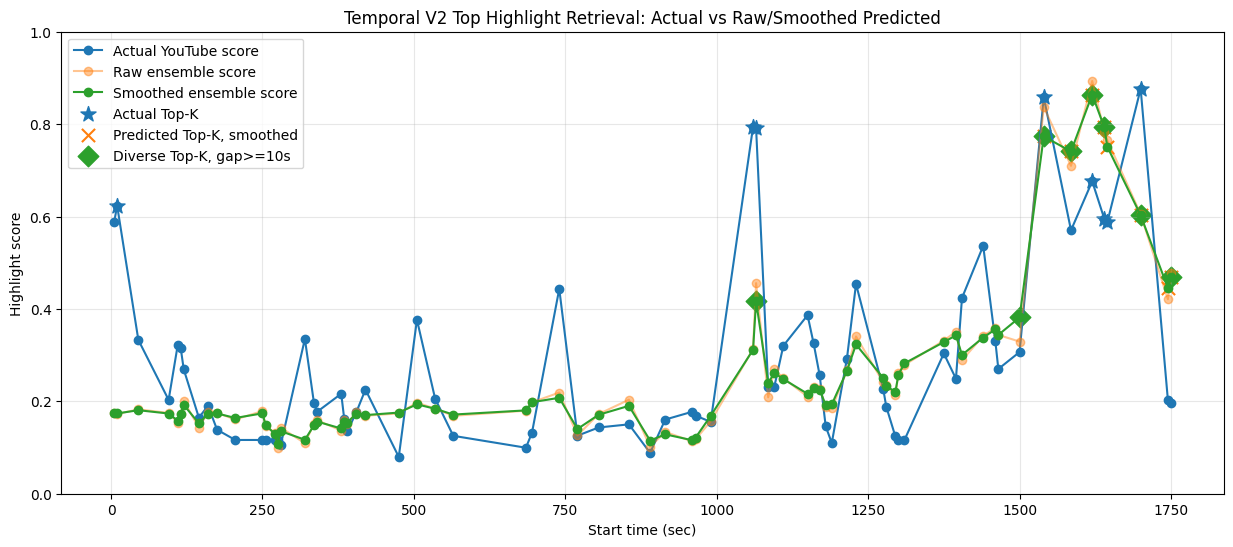

일반 예측 Top-K, raw:


,start_time,youtube_highlight_score,ensemble_prediction_raw,actual_top_k
65,1620,0.676205,0.893347,1
63,1540,0.858066,0.836906,1
66,1640,0.595035,0.784011,1
67,1645,0.587948,0.765092,1
64,1585,0.570219,0.709753,0
68,1700,0.876429,0.605010,1
70,1750,0.196155,0.478809,0
40,1065,0.791356,0.455813,1


일반 예측 Top-K, smoothed:


,start_time,youtube_highlight_score,ensemble_prediction_smoothed,actual_top_k
65,1620,0.676205,0.864054,1
66,1640,0.595035,0.793053,1
63,1540,0.858066,0.773429,1
67,1645,0.587948,0.750976,1
64,1585,0.570219,0.740828,0
68,1700,0.876429,0.602613,1
70,1750,0.196155,0.470131,0
69,1745,0.202422,0.445146,0


Diverse 예측 Top-K, smoothed:


,start_time,youtube_highlight_score,ensemble_prediction_smoothed,actual_top_k
65,1620,0.676205,0.864054,1
66,1640,0.595035,0.793053,1
63,1540,0.858066,0.773429,1
64,1585,0.570219,0.740828,0
68,1700,0.876429,0.602613,1
70,1750,0.196155,0.470131,0
40,1065,0.791356,0.416802,1
62,1500,0.306574,0.381495,0


In [69]:
k_test = top_k_count(len(test_df))
plot_df = test_df[["start_time", TARGET]].copy().reset_index(drop=True)
plot_df["ensemble_prediction_raw"] = ensemble_test_predictions
plot_df["ensemble_prediction_smoothed"] = ensemble_test_predictions_smoothed
plot_df["actual_top_k"] = 0
plot_df["predicted_top_k_raw"] = 0
plot_df["predicted_top_k_smoothed"] = 0
plot_df["predicted_diverse_top_k_smoothed"] = 0

actual_top_pos = np.argsort(y_test)[-k_test:]
pred_top_pos_raw = np.argsort(ensemble_test_predictions)[-k_test:]
pred_top_pos_smoothed = np.argsort(ensemble_test_predictions_smoothed)[-k_test:]
diverse_top_pos_smoothed = select_diverse_topk_indices(
    test_start_times, ensemble_test_predictions_smoothed, k_test, MIN_GAP_SEC
)

plot_df.iloc[actual_top_pos, plot_df.columns.get_loc("actual_top_k")] = 1
plot_df.iloc[pred_top_pos_raw, plot_df.columns.get_loc("predicted_top_k_raw")] = 1
plot_df.iloc[pred_top_pos_smoothed, plot_df.columns.get_loc("predicted_top_k_smoothed")] = 1
plot_df.iloc[diverse_top_pos_smoothed, plot_df.columns.get_loc("predicted_diverse_top_k_smoothed")] = 1

plt.figure(figsize=(15, 6))
plt.plot(plot_df["start_time"], plot_df[TARGET], marker="o", label="Actual YouTube score")
plt.plot(plot_df["start_time"], plot_df["ensemble_prediction_raw"], marker="o", alpha=0.45, label="Raw ensemble score")
plt.plot(plot_df["start_time"], plot_df["ensemble_prediction_smoothed"], marker="o", label="Smoothed ensemble score")
plt.scatter(
    plot_df.loc[plot_df["actual_top_k"].eq(1), "start_time"],
    plot_df.loc[plot_df["actual_top_k"].eq(1), TARGET],
    s=130,
    marker="*",
    label="Actual Top-K",
)
plt.scatter(
    plot_df.loc[plot_df["predicted_top_k_smoothed"].eq(1), "start_time"],
    plot_df.loc[plot_df["predicted_top_k_smoothed"].eq(1), "ensemble_prediction_smoothed"],
    s=90,
    marker="x",
    label="Predicted Top-K, smoothed",
)
plt.scatter(
    plot_df.loc[plot_df["predicted_diverse_top_k_smoothed"].eq(1), "start_time"],
    plot_df.loc[plot_df["predicted_diverse_top_k_smoothed"].eq(1), "ensemble_prediction_smoothed"],
    s=110,
    marker="D",
    label=f"Diverse Top-K, gap>={MIN_GAP_SEC}s",
)
plt.xlabel("Start time (sec)")
plt.ylabel("Highlight score")
plt.title("Temporal V2 Top Highlight Retrieval: Actual vs Raw/Smoothed Predicted")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("일반 예측 Top-K, raw:")
display(
    plot_df.sort_values("ensemble_prediction_raw", ascending=False)
    .head(k_test)[["start_time", TARGET, "ensemble_prediction_raw", "actual_top_k"]]
)

print("일반 예측 Top-K, smoothed:")
display(
    plot_df.sort_values("ensemble_prediction_smoothed", ascending=False)
    .head(k_test)[["start_time", TARGET, "ensemble_prediction_smoothed", "actual_top_k"]]
)

print("Diverse 예측 Top-K, smoothed:")
display(
    plot_df.iloc[diverse_top_pos_smoothed]
    .sort_values("ensemble_prediction_smoothed", ascending=False)[["start_time", TARGET, "ensemble_prediction_smoothed", "actual_top_k"]]
)


## 13-10. 최종 예측 및 결과 저장

In [70]:
all_ensemble_predictions = []
all_fitted_models = []
for key in top_keys:
    predictions, fitted = fit_single_candidate_for_test(key, np.arange(len(model_df)))
    all_ensemble_predictions.append(predictions)
    all_fitted_models.append({"candidate_key": key, "fitted": fitted})
all_ensemble_predictions = np.mean(all_ensemble_predictions, axis=0)
all_ensemble_predictions_smoothed = smooth_predictions_by_time(model_df, all_ensemble_predictions)

ranking_result_df = model_df.copy()
ranking_result_df["predicted_youtube_highlight_score_temporal_v2_raw"] = all_ensemble_predictions
ranking_result_df["predicted_youtube_highlight_score_temporal_v2_smoothed"] = all_ensemble_predictions_smoothed
ranking_result_df["temporal_v2_residual_smoothed"] = (
    ranking_result_df[TARGET] - ranking_result_df["predicted_youtube_highlight_score_temporal_v2_smoothed"]
)
ranking_result_df["data_split"] = "train"
ranking_result_df.loc[test_idx, "data_split"] = "stratified_test"

k_all = top_k_count(len(ranking_result_df))
ranking_result_df["predicted_top_highlight_raw"] = 0
ranking_result_df.iloc[
    np.argsort(ranking_result_df["predicted_youtube_highlight_score_temporal_v2_raw"].to_numpy())[-k_all:],
    ranking_result_df.columns.get_loc("predicted_top_highlight_raw"),
] = 1

ranking_result_df["predicted_top_highlight_smoothed"] = 0
ranking_result_df.iloc[
    np.argsort(ranking_result_df["predicted_youtube_highlight_score_temporal_v2_smoothed"].to_numpy())[-k_all:],
    ranking_result_df.columns.get_loc("predicted_top_highlight_smoothed"),
] = 1

ranking_result_df["predicted_top_highlight_diverse_smoothed"] = 0
diverse_all_pos = select_diverse_topk_indices(
    ranking_result_df["start_time"].to_numpy(),
    ranking_result_df["predicted_youtube_highlight_score_temporal_v2_smoothed"].to_numpy(),
    k_all,
    MIN_GAP_SEC,
)
ranking_result_df.iloc[
    diverse_all_pos,
    ranking_result_df.columns.get_loc("predicted_top_highlight_diverse_smoothed"),
] = 1

top_highlights_df = (
    ranking_result_df.sort_values("predicted_youtube_highlight_score_temporal_v2_smoothed", ascending=False)
    .head(k_all)
    .copy()
)
diverse_top_highlights_df = (
    ranking_result_df.iloc[diverse_all_pos]
    .sort_values("predicted_youtube_highlight_score_temporal_v2_smoothed", ascending=False)
    .copy()
)

prediction_path = MODEL_OUTPUT_DIR / "topk_temporal_v2_predictions_5sec.csv"
top_highlights_path = MODEL_OUTPUT_DIR / "predicted_top_highlights_temporal_v2_5sec.csv"
diverse_top_highlights_path = MODEL_OUTPUT_DIR / "predicted_top_highlights_temporal_v2_diverse_5sec.csv"
model_path = MODEL_OUTPUT_DIR / "youtube_highlight_topk_temporal_v2_models.joblib"
cv_path = MODEL_OUTPUT_DIR / "topk_temporal_v2_model_cv_comparison.csv"
test_path = MODEL_OUTPUT_DIR / "topk_temporal_v2_model_test_comparison.csv"
summary_path = MODEL_OUTPUT_DIR / "topk_temporal_v2_summary.json"

ranking_result_df.to_csv(prediction_path, index=False, encoding="utf-8-sig")
top_highlights_df.to_csv(top_highlights_path, index=False, encoding="utf-8-sig")
diverse_top_highlights_df.to_csv(diverse_top_highlights_path, index=False, encoding="utf-8-sig")
cv_results.to_csv(cv_path, index=False, encoding="utf-8-sig")
test_results.to_csv(test_path, index=False, encoding="utf-8-sig")

joblib.dump(
    {
        "feature_cols": FEATURE_COLS,
        "base_feature_cols": BASE_FEATURE_COLS,
        "added_feature_cols": ADDED_FEATURE_COLS,
        "emotion_features_to_impute": EMOTION_FEATURES_TO_IMPUTE,
        "candidate_specs": candidate_specs,
        "ensemble_models": all_fitted_models,
        "top_keys": top_keys,
        "top_rate": TOP_RATE,
        "highlight_weight": HIGHLIGHT_WEIGHT,
        "hybrid_alphas": HYBRID_ALPHAS,
        "min_gap_sec": MIN_GAP_SEC,
        "tolerance_sec": TOLERANCE_SEC,
        "pred_smooth_window_segments": PRED_SMOOTH_WINDOW_SEGMENTS,
        "label_smooth_window_segments": LABEL_SMOOTH_WINDOW_SEGMENTS,
        "rank_target": RANK_TARGET,
        "smooth_rank_target": SMOOTH_RANK_TARGET,
        "best_test_candidate": best_test_candidate,
        "note": "Temporal V2: rank regression + top-k classifier + local peak features + temporal label smoothing + prediction smoothing + tolerant evaluation.",
    },
    model_path,
)
summary_path.write_text(
    json.dumps(
        {
            "selection_goal": "retrieve top highlight segments",
            "improvements": [
                "rank target regression",
                "temporal label smoothing target for regression",
                "previous 15-second temporal contrast features",
                "local peak features",
                "top-k binary classifier",
                "regression-classifier hybrid score",
                "prediction smoothing on the time axis",
                "tolerant evaluation with ±10 seconds",
                "diverse top-k post-processing",
            ],
            "top_rate": TOP_RATE,
            "highlight_weight": HIGHLIGHT_WEIGHT,
            "hybrid_alphas": HYBRID_ALPHAS,
            "min_gap_sec": MIN_GAP_SEC,
            "tolerance_sec": TOLERANCE_SEC,
            "pred_smooth_window_segments": PRED_SMOOTH_WINDOW_SEGMENTS,
            "pred_smooth_raw_weight": PRED_SMOOTH_RAW_WEIGHT,
            "label_smooth_window_segments": LABEL_SMOOTH_WINDOW_SEGMENTS,
            "label_smooth_raw_weight": LABEL_SMOOTH_RAW_WEIGHT,
            "best_test_candidate": best_test_candidate,
            "ensemble_members": top_keys,
            "ensemble_cv_metrics": ensemble_cv_metrics,
            "ensemble_test_metrics_raw": top_highlight_metrics(y_test, ensemble_test_predictions, start_times=test_start_times),
            "ensemble_test_metrics_smoothed": top_highlight_metrics(y_test, ensemble_test_predictions_smoothed, start_times=test_start_times),
            "mean_only_test_baseline_metrics": top_highlight_metrics(y_test, baseline_predictions, start_times=test_start_times),
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("저장 완료:")
for path in [
    prediction_path,
    top_highlights_path,
    diverse_top_highlights_path,
    model_path,
    cv_path,
    test_path,
    summary_path,
]:
    print("-", path)


저장 완료:
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_topk_output_temporal_v2/topk_temporal_v2_predictions_5sec.csv
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_topk_output_temporal_v2/predicted_top_highlights_temporal_v2_5sec.csv
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_topk_output_temporal_v2/predicted_top_highlights_temporal_v2_diverse_5sec.csv
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_topk_output_temporal_v2/youtube_highlight_topk_temporal_v2_models.joblib
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_topk_output_temporal_v2/topk_temporal_v2_model_cv_comparison.csv
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_topk_output_temporal_v2/topk_temporal_v2_model_test_comparison.csv
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_topk_output_temporal_v2/topk_temporal_v2_summary.json


## 13-11. 저장 결과 확인

In [71]:
print("결과 폴더:", MODEL_OUTPUT_DIR.resolve())
for path in sorted(MODEL_OUTPUT_DIR.iterdir()):
    print("-", path.name)


결과 폴더: /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_topk_output_temporal_v2
- predicted_top_highlights_temporal_v2_5sec.csv
- predicted_top_highlights_temporal_v2_diverse_5sec.csv
- topk_temporal_v2_model_cv_comparison.csv
- topk_temporal_v2_model_test_comparison.csv
- topk_temporal_v2_predictions_5sec.csv
- topk_temporal_v2_summary.json
- youtube_highlight_topk_temporal_v2_models.joblib


## 9-1. 시각화 그래프 생성 실행


[6단계] 시각화 그래프 생성
시각화 저장 완료
/content/drive/MyDrive/인지프/aeaa_lora_weights/emotion_distribution_by_character.png


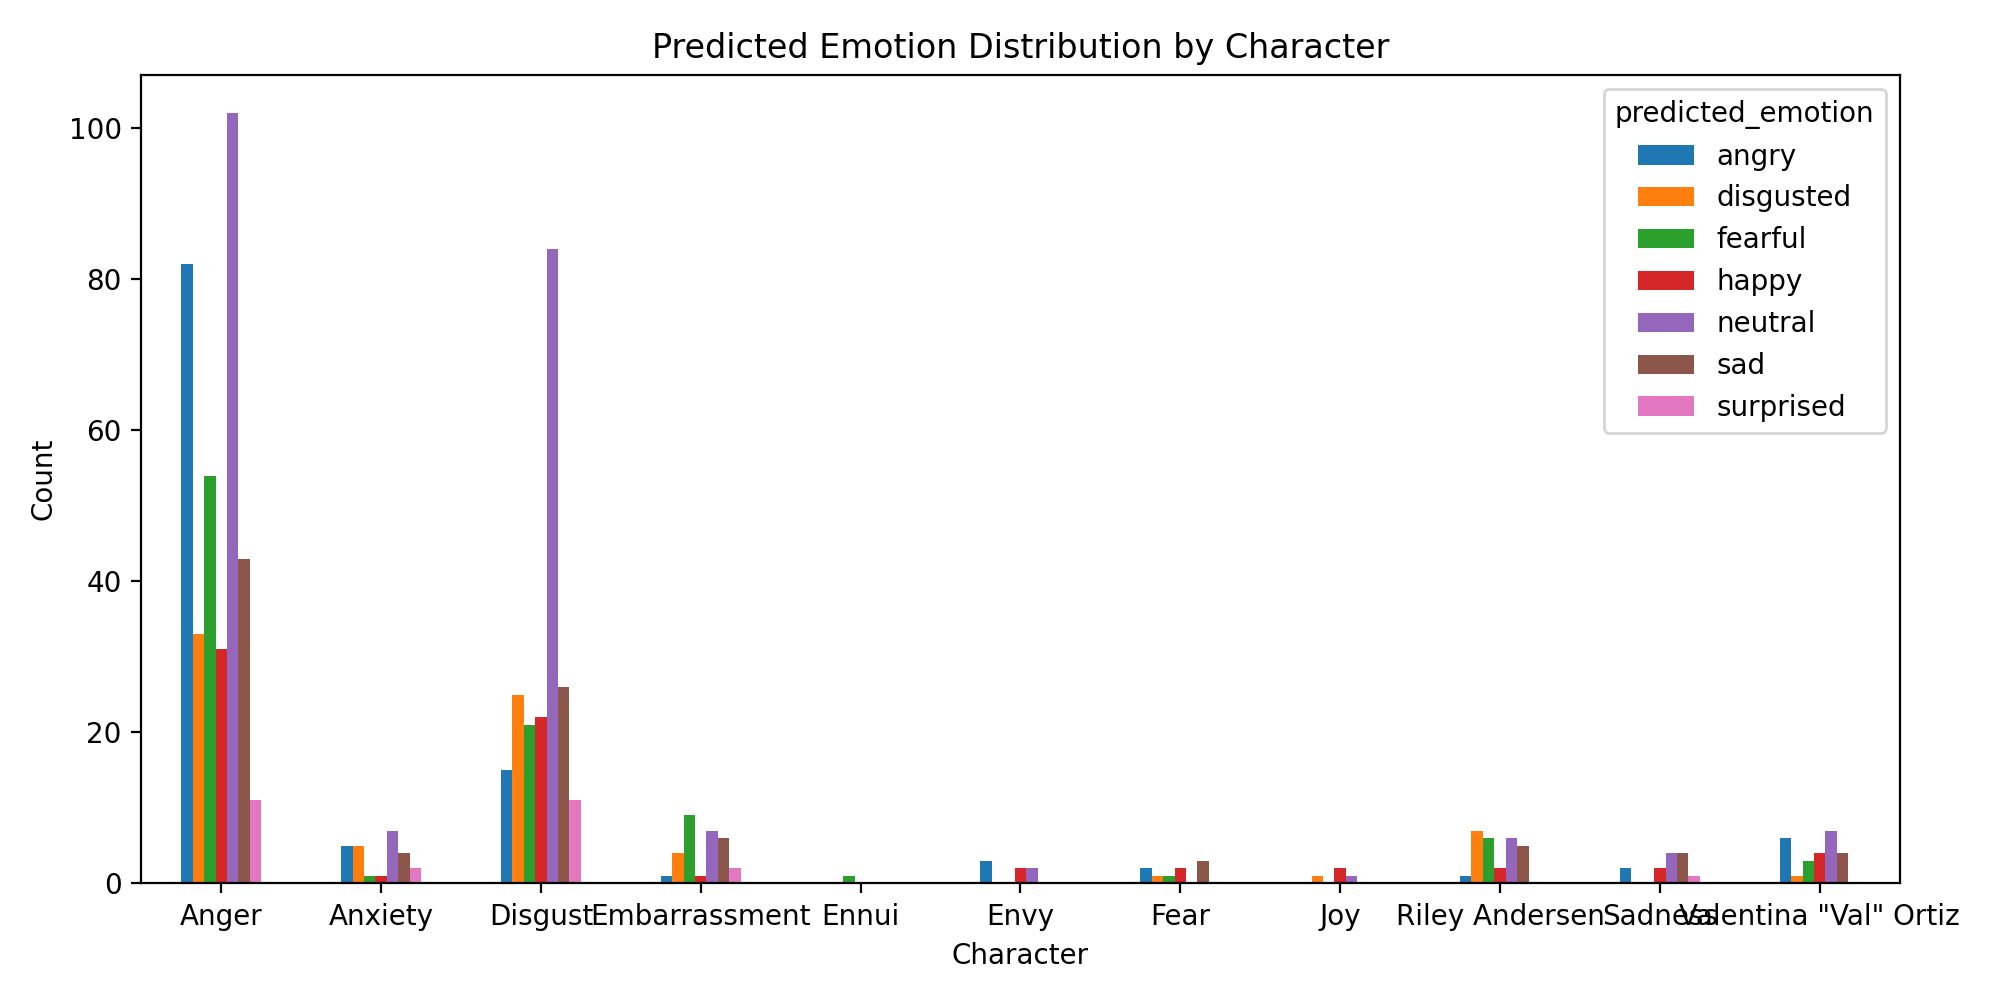

/content/drive/MyDrive/인지프/aeaa_lora_weights/mismatch_score_timeline.png


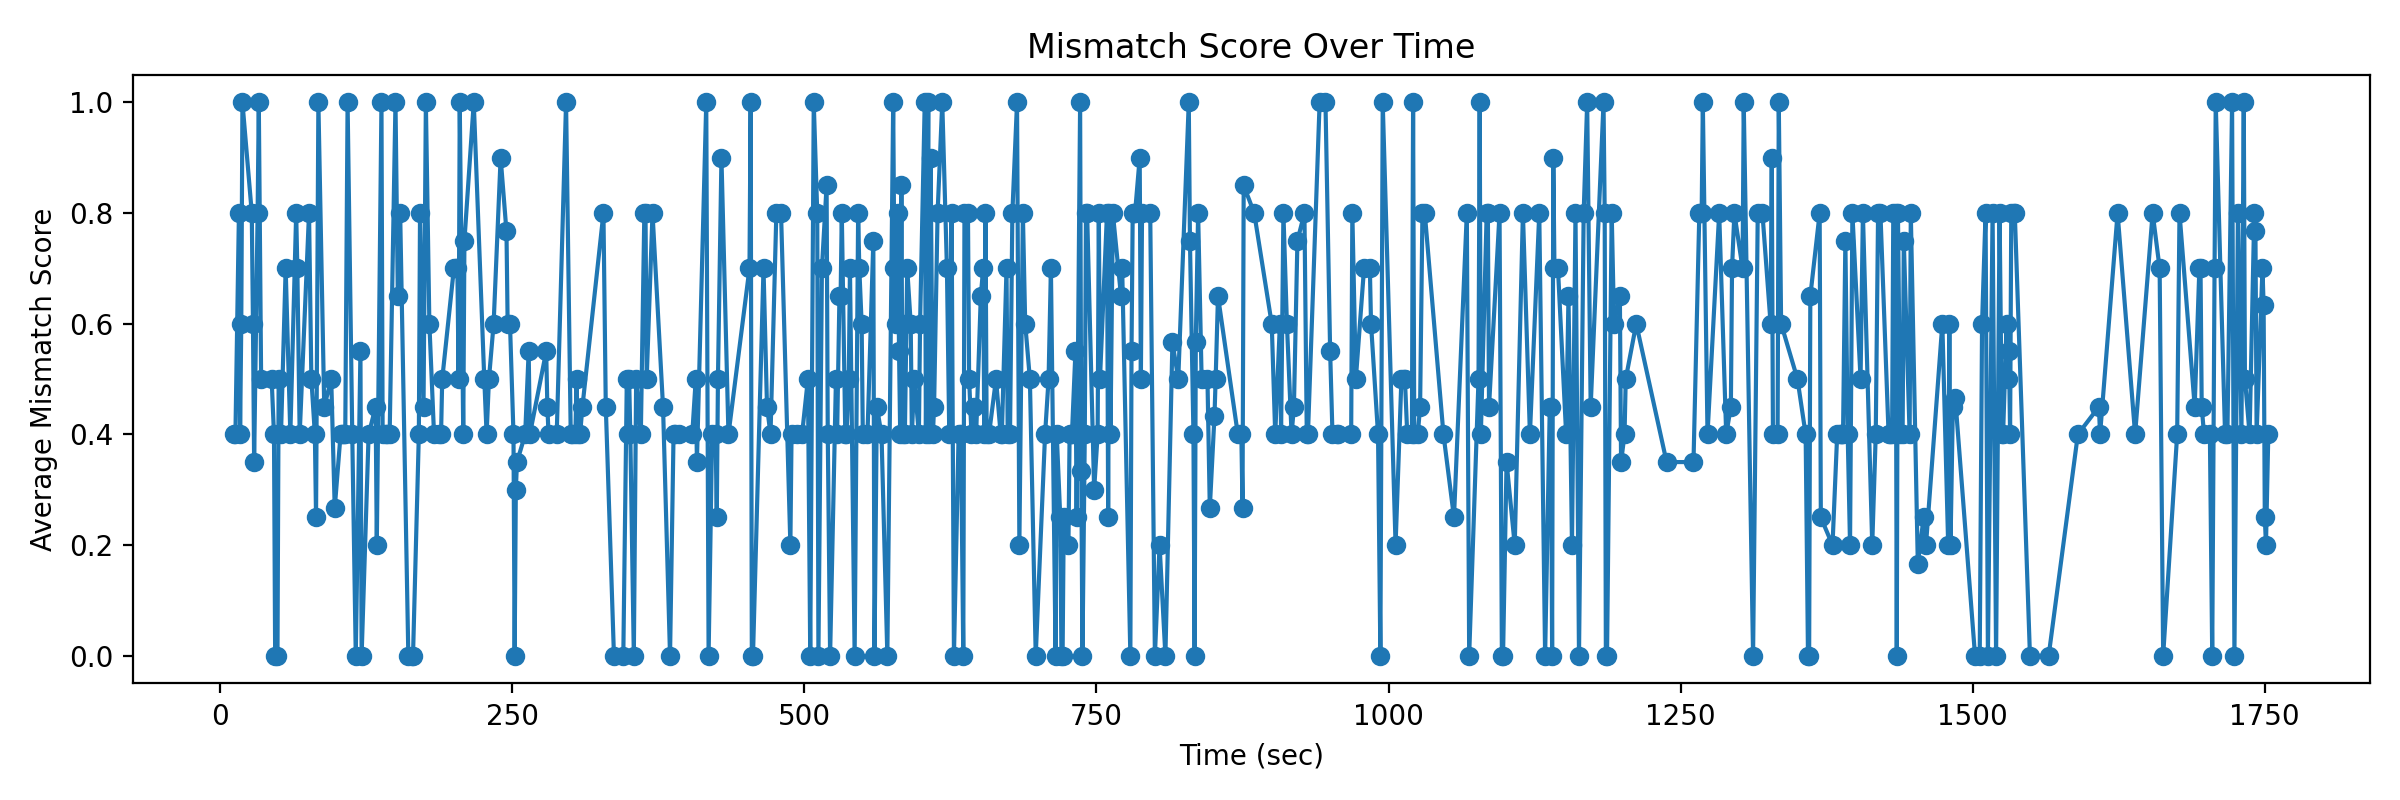

/content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_score_timeline.png


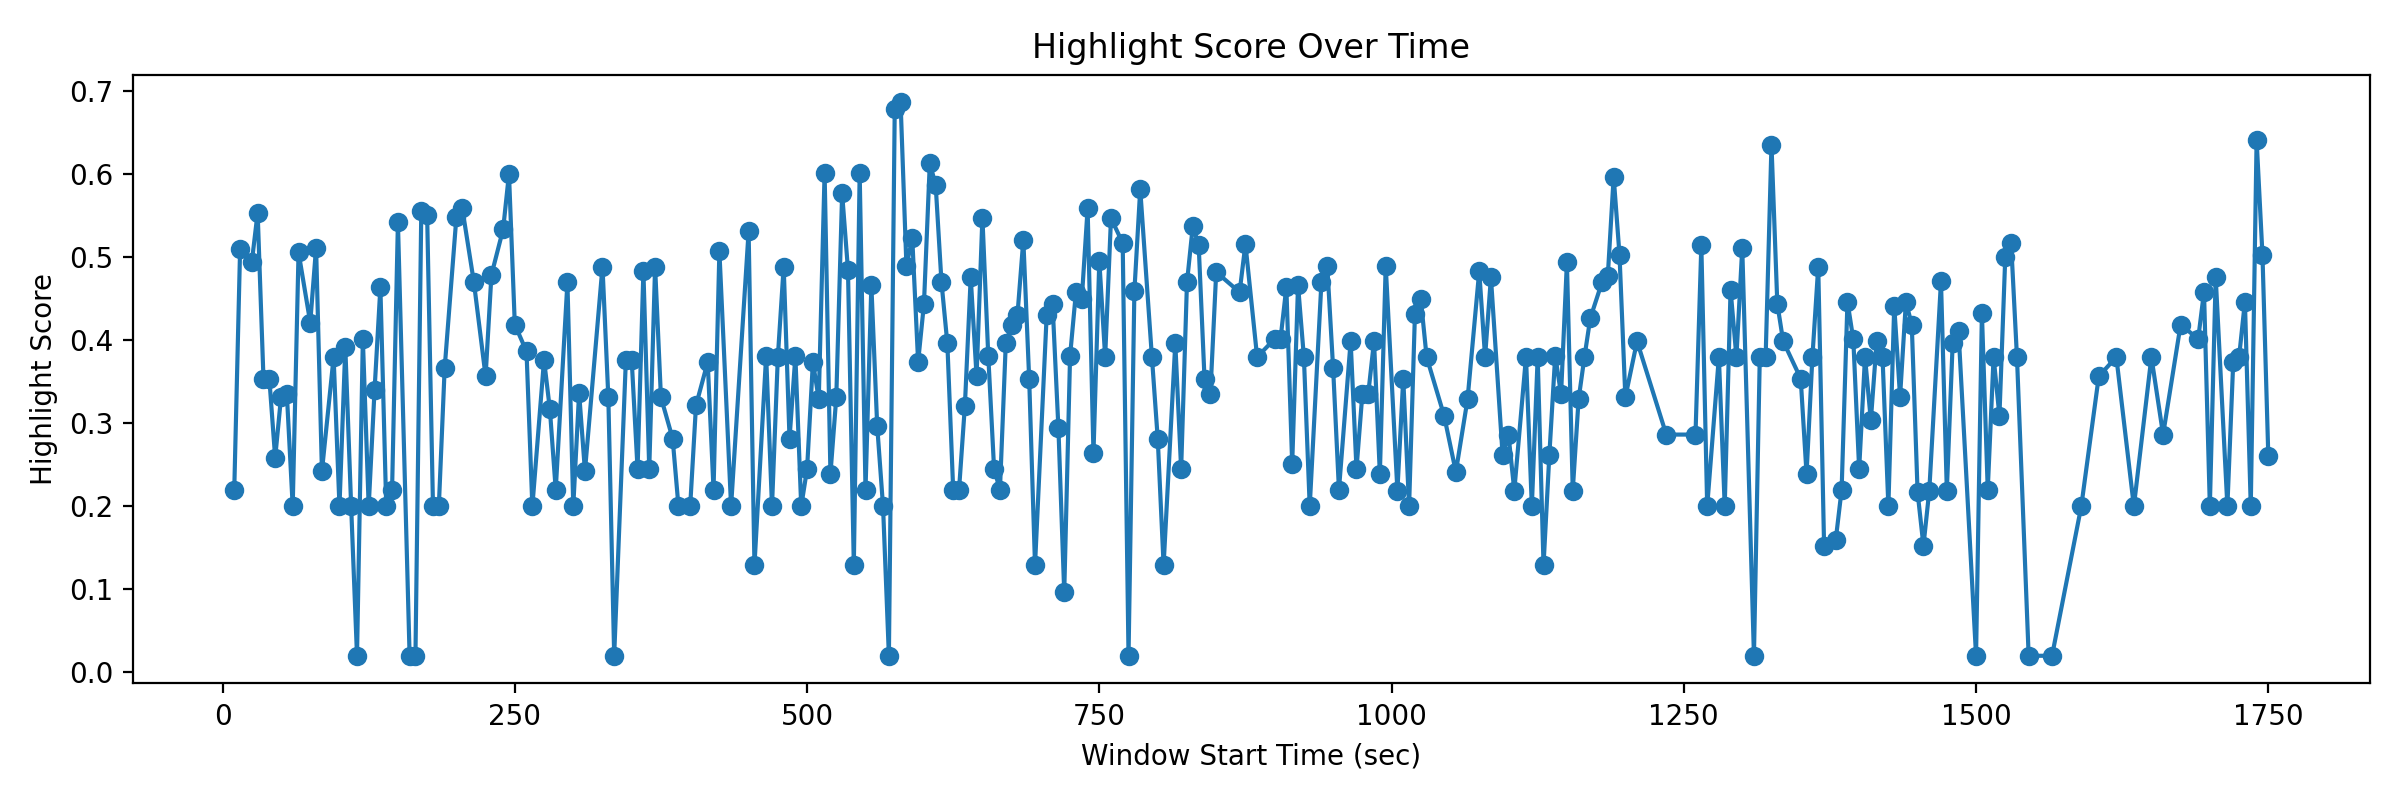

In [72]:
make_visualizations(result_df, score_df)

from IPython.display import Image as IPyImage, display as ipy_display
for p in [
    f'{OUTPUT_DIR}/emotion_distribution_by_character.png',
    f'{OUTPUT_DIR}/mismatch_score_timeline.png',
    f'{OUTPUT_DIR}/highlight_score_timeline.png',
]:
    if os.path.exists(p):
        print(p)
        ipy_display(IPyImage(filename=p, width=800))

## 10-1. 하이라이트 클립 및 결과 영상 생성 실행

In [73]:
top_highlights_df = extract_highlight_clips(VIDEO_PATH, score_df, top_k=TOP_K_HIGHLIGHTS, clip_margin=2)
make_annotated_video(frame_df, f'{OUTPUT_DIR}/annotated_demo_video.mp4', fps=SAMPLE_FPS)
display(top_highlights_df)


[7단계] 하이라이트 후보 클립 추출
하이라이트 클립 저장: /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_clips/highlight_93_score_0.687.mp4
하이라이트 클립 저장: /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_clips/highlight_92_score_0.679.mp4
하이라이트 클립 저장: /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_clips/highlight_265_score_0.642.mp4

[8단계] annotated demo video 생성
annotated frame이 없습니다.


,start_sec,end_sec,start_time,end_time,num_detections,character_count,emotion_count,avg_mismatch,emotion_entropy,transition_score,avg_emotion_confidence,highlight_score
93,580,585,09:40,09:45,7,2,4,0.628571,0.656266,1.0,0.394129,0.686924
92,575,580,09:35,09:40,7,4,4,0.700000,0.656266,0.6,0.355216,0.679066
265,1740,1745,29:00,29:05,5,4,5,0.700000,0.827087,0.2,0.352569,0.641772


## 11-1. 요약 리포트 생성 실행

In [74]:
make_summary_report(result_df, score_df)
report_path = f'{OUTPUT_DIR}/summary_report.txt'
with open(report_path, 'r', encoding='utf-8') as f:
    print(f.read())


[9단계] 요약 리포트 생성
요약 리포트 저장 완료: /content/drive/MyDrive/인지프/aeaa_lora_weights/summary_report.txt
Inside Out 2 감정 캐릭터 표정 분석 데모 리포트

[분석 대상 캐릭터]
- Riley Andersen(라일리 앤더슨): 기대 감정 = neutral
- Joy(기쁨): 기대 감정 = happy
- Sadness(슬픔): 기대 감정 = sad
- Anger(버럭): 기대 감정 = angry
- Fear(겁): 기대 감정 = fearful
- Disgust(시기): 기대 감정 = disgusted
- Anxiety(불안): 기대 감정 = fearful
- Envy(질투): 기대 감정 = angry
- Ennui(무기력): 기대 감정 = neutral
- Embarrassment(당황): 기대 감정 = fearful
- Valentina "Val" Ortiz(발렌티나 "발" 오르티즈): 기대 감정 = neutral

[전체 탐지 결과]
- 총 탐지 crop 수: 701
- 등장 캐릭터 수: 11

[캐릭터별 탐지 수]
character
Anger                    356
Disgust                  204
Embarrassment             30
Riley Andersen            27
Anxiety                   25
Valentina "Val" Ortiz     25
Sadness                   13
Fear                       9
Envy                       7
Joy                        4
Ennui                      1

[예측 감정 분포]
predicted_emotion
neutral      220
angry        117
fearful       96
sad           95
disgusted  

## 12. 최종 결과 파일 확인

In [75]:
print('전체 완료!')
print(f'결과 폴더: {OUTPUT_DIR}')
print('\n주요 결과 파일')
print(f'- {OUTPUT_DIR}/character_emotion_results.csv')
print(f'- {OUTPUT_DIR}/highlight_scores.csv')
print(f'- {OUTPUT_DIR}/summary_report.txt')
print(f'- {OUTPUT_DIR}/annotated_demo_video.mp4')
print(f'- {OUTPUT_DIR}/emotion_distribution_by_character.png')
print(f'- {OUTPUT_DIR}/mismatch_score_timeline.png')
print(f'- {OUTPUT_DIR}/highlight_score_timeline.png')
print(f'- {OUTPUT_DIR}/highlight_clips/')

전체 완료!
결과 폴더: /content/drive/MyDrive/인지프/aeaa_lora_weights

주요 결과 파일
- /content/drive/MyDrive/인지프/aeaa_lora_weights/character_emotion_results.csv
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_scores.csv
- /content/drive/MyDrive/인지프/aeaa_lora_weights/summary_report.txt
- /content/drive/MyDrive/인지프/aeaa_lora_weights/annotated_demo_video.mp4
- /content/drive/MyDrive/인지프/aeaa_lora_weights/emotion_distribution_by_character.png
- /content/drive/MyDrive/인지프/aeaa_lora_weights/mismatch_score_timeline.png
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_score_timeline.png
- /content/drive/MyDrive/인지프/aeaa_lora_weights/highlight_clips/
